# V6 Step 8: Evaluation, EER, Multi-seed Summary

This notebook evaluates the existing V6 Step 7 RP-only RanPAC outputs. It does not rerun Random Projection or RanPAC, does not include no-RP baselines, and does not create dim1000 experiments.


**Presentation note:** A defense demo section is added at the end of this notebook. It loads saved outputs, displays key tables and figures, and provides a small code-based result viewer.


In [1]:
from pathlib import Path
import json
import math
import re

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont

ROOT = Path(r"F:\ECG")
STEP7_SUMMARY_PATH = ROOT / "data" / "processed" / "ranpac_v6" / "ranpac_v6_summary.csv"
OUTPUT_DIR = ROOT / "results" / "eval_v6"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
EER_CURVE_DIR = OUTPUT_DIR / "eer_curves"
REPORT_DIR = OUTPUT_DIR / "reports"

FINAL_TABLE_PATH = TABLE_DIR / "final_v6_135.csv"
MEAN_STD_PATH = TABLE_DIR / "mean_std_v6.csv"
REPORT_PATH = REPORT_DIR / "v6_report.md"
NOTEBOOK_PATH = ROOT / "notebooks" / "08_v6_eval.ipynb"

EXPECTED_INPUT_ROWS = 135
EXPECTED_MEAN_STD_ROWS = 45
EXPECTED_NUM_SEEDS = 3
STABILITY_DOWNSAMPLE_STEP = 100

for folder in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, EER_CURVE_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

REQUIRED_SCORE_ARRAYS = [
    "true_labels",
    "predicted_labels",
    "correct_flags",
    "seen_class_before_flags",
    "true_scores",
    "max_non_true_scores",
    "strict_counted_flags",
    "enrollment_aware_counted_flags",
]

print("Notebook path =", NOTEBOOK_PATH)
print("Input Step 7 summary =", STEP7_SUMMARY_PATH)
print("Output folder =", OUTPUT_DIR)


Notebook path = F:\ECG\notebooks\08_v6_eval.ipynb
Input Step 7 summary = F:\ECG\data\processed\ranpac_v6\ranpac_v6_summary.csv
Output folder = F:\ECG\results\eval_v6


## 1. Validate V6 Step 7 inputs

Step 8 starts from the V6 Step 7 summary. It must contain exactly 135 RP-only rows, with no no-RP baseline rows.


In [2]:
def require(condition, message):
    if not condition:
        raise RuntimeError(message)


def as_bool_series(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.strip().str.lower().map({
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False,
    })


require(STEP7_SUMMARY_PATH.exists(), f"Missing V6 Step 7 summary: {STEP7_SUMMARY_PATH}")
step7_df = pd.read_csv(STEP7_SUMMARY_PATH)
input_step7_rows = int(len(step7_df))

is_rp_flags = as_bool_series(step7_df["is_rp"])
is_baseline_flags = as_bool_series(step7_df["is_baseline"])
no_norp_input = bool(
    is_rp_flags.all()
    and (~is_baseline_flags).all()
    and (step7_df["rp_alias"].astype(str) != "norp").all()
    and (step7_df["seed_label"].astype(str) != "norp").all()
)

score_outputs_exist_input = bool(step7_df["score_output_path"].map(lambda path: Path(str(path)).exists()).all())
prediction_logs_exist_input = bool(step7_df["prediction_log_path"].map(lambda path: Path(str(path)).exists()).all())

require(input_step7_rows == EXPECTED_INPUT_ROWS, f"Expected 135 V6 Step 7 rows, got {input_step7_rows}")
require(no_norp_input, "V6 Step 7 summary includes no-RP or baseline rows")
require(score_outputs_exist_input, "Some score outputs are missing")
require(prediction_logs_exist_input, "Some prediction logs are missing")

print("Input Step 7 rows =", input_step7_rows)
print("RP-only rows =", int(is_rp_flags.sum()))
print("No no-RP rows in input =", no_norp_input)
print("Score outputs exist =", score_outputs_exist_input)
print("Prediction logs exist =", prediction_logs_exist_input)


Input Step 7 rows = 135
RP-only rows = 135
No no-RP rows in input = True
Score outputs exist = True
Prediction logs exist = True


## 2. EER helper functions

EER uses genuine score = true_score and impostor score = max_non_true_score. NaN/Inf scores are filtered because early stream samples can have no previously seen class.


In [3]:
def compute_eer_curve(genuine_scores, impostor_scores):
    genuine_scores = np.asarray(genuine_scores, dtype=float)
    impostor_scores = np.asarray(impostor_scores, dtype=float)
    valid_mask = np.isfinite(genuine_scores) & np.isfinite(impostor_scores)
    genuine_scores = genuine_scores[valid_mask]
    impostor_scores = impostor_scores[valid_mask]

    if len(genuine_scores) == 0 or len(impostor_scores) == 0:
        empty_curve = pd.DataFrame(columns=["threshold", "FAR", "FRR", "abs_FAR_minus_FRR"])
        return {
            "eer": np.nan,
            "threshold": np.nan,
            "curve": empty_curve,
            "num_samples": 0,
        }

    all_scores = np.concatenate([genuine_scores, impostor_scores])
    min_score = float(np.min(all_scores))
    max_score = float(np.max(all_scores))
    score_span = max(max_score - min_score, 1.0)
    epsilon = score_span * 1e-6
    thresholds = np.unique(np.concatenate([[min_score - epsilon], all_scores, [max_score + epsilon]]))
    thresholds.sort()

    genuine_sorted = np.sort(genuine_scores)
    impostor_sorted = np.sort(impostor_scores)

    frr = np.searchsorted(genuine_sorted, thresholds, side="left") / len(genuine_sorted)
    far = (len(impostor_sorted) - np.searchsorted(impostor_sorted, thresholds, side="left")) / len(impostor_sorted)
    abs_diff = np.abs(far - frr)
    best_index = int(np.argmin(abs_diff))

    curve = pd.DataFrame({
        "threshold": thresholds,
        "FAR": far,
        "FRR": frr,
        "abs_FAR_minus_FRR": abs_diff,
    })

    return {
        "eer": float((far[best_index] + frr[best_index]) / 2.0),
        "threshold": float(thresholds[best_index]),
        "curve": curve,
        "num_samples": int(len(genuine_scores)),
    }


def clean_name(value):
    text = str(value)
    text = re.sub(r"[^A-Za-z0-9_\-]+", "_", text)
    return re.sub(r"_+", "_", text).strip("_")


## 3. Compute EER and save final per-experiment table

This cell computes strict valid EER and enrollment-aware EER for all 135 experiments, then saves `final_v6_135.csv`.


In [4]:
final_rows = []

for _, row in step7_df.iterrows():
    score_path = Path(str(row["score_output_path"]))
    score_data = np.load(score_path, allow_pickle=False)
    missing_arrays = [name for name in REQUIRED_SCORE_ARRAYS if name not in score_data.files]
    require(not missing_arrays, f"Missing score arrays in {score_path}: {missing_arrays}")

    true_scores = score_data["true_scores"].astype(float)
    max_non_true_scores = score_data["max_non_true_scores"].astype(float)
    enrollment_flags = score_data["enrollment_aware_counted_flags"].astype(bool)

    valid_score_mask = np.isfinite(true_scores) & np.isfinite(max_non_true_scores)
    enrollment_score_mask = valid_score_mask & enrollment_flags

    strict_eer_result = compute_eer_curve(true_scores[valid_score_mask], max_non_true_scores[valid_score_mask])
    enrollment_eer_result = compute_eer_curve(true_scores[enrollment_score_mask], max_non_true_scores[enrollment_score_mask])

    final_rows.append({
        "experiment_id": row["experiment_id"],
        "feature_setting_full": row["feature_setting_full"],
        "feature_alias": row["feature_alias"],
        "rp_method_full": row["rp_method_full"],
        "rp_alias": row["rp_alias"],
        "projection_dim": int(row["projection_dim"]),
        "output_dim": int(row["output_dim"]),
        "seed": int(row["seed"]),
        "seed_label": row["seed_label"],
        "strict_prequential_accuracy": float(row["strict_prequential_accuracy"]),
        "enrollment_aware_accuracy": float(row["enrollment_aware_accuracy"]),
        "strict_macro_f1": float(row["strict_macro_f1"]),
        "enrollment_aware_macro_f1": float(row["enrollment_aware_macro_f1"]),
        "strict_valid_eer": strict_eer_result["eer"],
        "enrollment_aware_eer": enrollment_eer_result["eer"],
        "strict_eer_threshold": strict_eer_result["threshold"],
        "enrollment_aware_eer_threshold": enrollment_eer_result["threshold"],
        "num_valid_score_samples": int(valid_score_mask.sum()),
        "num_enrollment_aware_score_samples": int(enrollment_score_mask.sum()),
        "runtime_seconds": float(row["runtime_seconds"]),
        "prediction_log_path": row["prediction_log_path"],
        "score_output_path": row["score_output_path"],
    })

final_df = pd.DataFrame(final_rows)
require(len(final_df) == EXPECTED_INPUT_ROWS, f"Expected 135 final rows, got {len(final_df)}")
require(final_df[["strict_valid_eer", "enrollment_aware_eer"]].notna().all().all(), "Some EER values were not computed")
final_df.to_csv(FINAL_TABLE_PATH, index=False, encoding="utf-8-sig")

print("Final per-experiment rows =", len(final_df))
print("EER computed for all 135 =", final_df[["strict_valid_eer", "enrollment_aware_eer"]].notna().all().all())
print("Saved final table =", FINAL_TABLE_PATH)


Final per-experiment rows = 135
EER computed for all 135 = True
Saved final table = F:\ECG\results\eval_v6\tables\final_v6_135.csv


## 4. Multi-seed mean/std summary and rankings

The 135 per-experiment rows are aggregated into 45 unique feature/method/dimension settings, each with three seeds.


In [5]:
group_cols = [
    "feature_setting_full",
    "feature_alias",
    "rp_method_full",
    "rp_alias",
    "projection_dim",
]

mean_std_v6 = (
    final_df
    .groupby(group_cols, as_index=False)
    .agg(
        mean_enrollment_aware_accuracy=("enrollment_aware_accuracy", "mean"),
        std_enrollment_aware_accuracy=("enrollment_aware_accuracy", "std"),
        mean_enrollment_aware_macro_f1=("enrollment_aware_macro_f1", "mean"),
        std_enrollment_aware_macro_f1=("enrollment_aware_macro_f1", "std"),
        mean_enrollment_aware_eer=("enrollment_aware_eer", "mean"),
        std_enrollment_aware_eer=("enrollment_aware_eer", "std"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        std_runtime_seconds=("runtime_seconds", "std"),
        num_seeds=("seed", "nunique"),
    )
    .sort_values(group_cols)
    .reset_index(drop=True)
)

require(len(mean_std_v6) == EXPECTED_MEAN_STD_ROWS, f"Expected 45 mean/std rows, got {len(mean_std_v6)}")
require((mean_std_v6["num_seeds"] == EXPECTED_NUM_SEEDS).all(), "Not every mean/std row has 3 seeds")

mean_std_v6["rank_by_mean_accuracy"] = mean_std_v6["mean_enrollment_aware_accuracy"].rank(ascending=False, method="min").astype(int)
mean_std_v6["rank_by_mean_macro_f1"] = mean_std_v6["mean_enrollment_aware_macro_f1"].rank(ascending=False, method="min").astype(int)
mean_std_v6["rank_by_mean_eer"] = mean_std_v6["mean_enrollment_aware_eer"].rank(ascending=True, method="min").astype(int)
mean_std_v6["overall_rank_score"] = (
    mean_std_v6["rank_by_mean_accuracy"]
    + mean_std_v6["rank_by_mean_macro_f1"]
    + mean_std_v6["rank_by_mean_eer"]
)

mean_std_v6.to_csv(MEAN_STD_PATH, index=False, encoding="utf-8-sig")

ranking_tables = {
    "top10_acc.csv": mean_std_v6.sort_values(
        ["mean_enrollment_aware_accuracy", "mean_enrollment_aware_macro_f1", "mean_enrollment_aware_eer"],
        ascending=[False, False, True],
    ).head(10),
    "top10_f1.csv": mean_std_v6.sort_values(
        ["mean_enrollment_aware_macro_f1", "mean_enrollment_aware_accuracy", "mean_enrollment_aware_eer"],
        ascending=[False, False, True],
    ).head(10),
    "top10_eer.csv": mean_std_v6.sort_values(
        ["mean_enrollment_aware_eer", "mean_enrollment_aware_accuracy", "mean_enrollment_aware_macro_f1"],
        ascending=[True, False, False],
    ).head(10),
    "top10_balanced.csv": mean_std_v6.sort_values(
        ["overall_rank_score", "rank_by_mean_accuracy", "rank_by_mean_eer"],
        ascending=[True, True, True],
    ).head(10),
}

for file_name, table in ranking_tables.items():
    table.to_csv(TABLE_DIR / file_name, index=False, encoding="utf-8-sig")

print("Mean/std rows =", len(mean_std_v6))
print("Every mean/std row has num_seeds = 3 =", bool((mean_std_v6["num_seeds"] == 3).all()))
print("Ranking tables saved =", all((TABLE_DIR / name).exists() for name in ranking_tables))
print("Best balanced setting:")
print(ranking_tables["top10_balanced.csv"].head(1).to_string(index=False))


Mean/std rows = 45
Every mean/std row has num_seeds = 3 = True
Ranking tables saved = True
Best balanced setting:
feature_setting_full feature_alias     rp_method_full rp_alias  projection_dim  mean_enrollment_aware_accuracy  std_enrollment_aware_accuracy  mean_enrollment_aware_macro_f1  std_enrollment_aware_macro_f1  mean_enrollment_aware_eer  std_enrollment_aware_eer  mean_runtime_seconds  std_runtime_seconds  num_seeds  rank_by_mean_accuracy  rank_by_mean_macro_f1  rank_by_mean_eer  overall_rank_score
  embedding_resnet1d           emb bernoulli_gaussian       bg             500                        0.818863                       0.000803                        0.785632                       0.001296                    0.21421                  0.000584             41.339193             4.177451          3                      1                      1                 1                   3


## 5. Group-level comparison tables

Group-level comparisons are computed from the 45-row mean/std table, not from the 135 raw seed rows.


In [6]:
GROUP_METRICS = [
    "mean_enrollment_aware_accuracy",
    "mean_enrollment_aware_macro_f1",
    "mean_enrollment_aware_eer",
    "mean_runtime_seconds",
]

def make_group_table(data, group_col):
    rows = []
    for group_value, group_data in data.groupby(group_col, dropna=False):
        out = {group_col: group_value}
        for metric in GROUP_METRICS:
            values = group_data[metric].astype(float)
            out[f"{metric}_mean"] = float(values.mean())
            out[f"{metric}_std"] = float(values.std(ddof=1))
            if metric in ["mean_enrollment_aware_eer", "mean_runtime_seconds"]:
                out[f"{metric}_best"] = float(values.min())
                out[f"{metric}_worst"] = float(values.max())
            else:
                out[f"{metric}_best"] = float(values.max())
                out[f"{metric}_worst"] = float(values.min())
        rows.append(out)
    return pd.DataFrame(rows)

by_feature = make_group_table(mean_std_v6, "feature_setting_full")
by_method = make_group_table(mean_std_v6, "rp_method_full")
by_dim = make_group_table(mean_std_v6, "projection_dim")

by_feature.to_csv(TABLE_DIR / "by_feature.csv", index=False, encoding="utf-8-sig")
by_method.to_csv(TABLE_DIR / "by_method.csv", index=False, encoding="utf-8-sig")
by_dim.to_csv(TABLE_DIR / "by_dim.csv", index=False, encoding="utf-8-sig")

group_table_paths = [TABLE_DIR / "by_feature.csv", TABLE_DIR / "by_method.csv", TABLE_DIR / "by_dim.csv"]
print("Group tables saved =", all(path.exists() for path in group_table_paths))


Group tables saved = True


## 6. Plot helper functions

Figures are generated as PNG files under `results/eval_v6/figures`, separate from all V5 figures.


In [7]:
def load_font(size=18, bold=False):
    candidates = []
    if bold:
        candidates += [r"C:\Windows\Fonts\arialbd.ttf", r"C:\Windows\Fonts\calibrib.ttf"]
    candidates += [r"C:\Windows\Fonts\arial.ttf", r"C:\Windows\Fonts\calibri.ttf"]
    for candidate in candidates:
        try:
            if Path(candidate).exists():
                return ImageFont.truetype(candidate, size=size)
        except Exception:
            pass
    return ImageFont.load_default()


FONT_TITLE = load_font(26, bold=True)
FONT_AXIS = load_font(18)
FONT_SMALL = load_font(14)
FONT_TINY = load_font(12)

FONT_TITLE_CLEAR = load_font(34, bold=True)
FONT_AXIS_CLEAR = load_font(24)
FONT_TICK_CLEAR = load_font(24)
FONT_VALUE_CLEAR = load_font(24, bold=True)
FONT_LABEL_CLEAR = load_font(24)

COLORS = {
    "blue": (52, 111, 173),
    "orange": (226, 132, 45),
    "green": (72, 153, 92),
    "red": (194, 77, 72),
    "purple": (120, 95, 170),
    "gray": (95, 95, 95),
    "light_gray": (232, 235, 240),
    "dark": (30, 35, 42),
    "white": (255, 255, 255),
}
PALETTE = [COLORS["blue"], COLORS["orange"], COLORS["green"], COLORS["red"], COLORS["purple"], (70, 150, 160), (160, 110, 60)]


def label_text(row):
    return f"{row['feature_alias']}_{row['rp_alias']}_d{int(row['projection_dim'])}"


def draw_centered(draw, xy, text, font, fill):
    x, y = xy
    box = draw.textbbox((0, 0), str(text), font=font)
    draw.text((x - (box[2] - box[0]) / 2, y), str(text), font=font, fill=fill)


def save_bar_chart(table, category_col, value_col, output_path, title, x_label, y_label, color):
    table = table.copy()
    values = table[value_col].astype(float).to_numpy()
    labels = table[category_col].astype(str).tolist()
    width, height = 1120, 760
    plot_left, plot_right, plot_top, plot_bottom = 120, width - 70, 105, height - 175
    plot_width, plot_height = plot_right - plot_left, plot_bottom - plot_top
    image = Image.new("RGB", (width, height), COLORS["white"])
    draw = ImageDraw.Draw(image)
    draw_centered(draw, (width / 2, 28), title, FONT_TITLE, COLORS["dark"])
    draw_centered(draw, (width / 2, height - 48), x_label, FONT_AXIS, COLORS["dark"])
    draw.text((18, 34), y_label, font=FONT_AXIS, fill=COLORS["dark"])

    y_min = min(0.0, float(values.min()) * 0.95)
    y_max = max(float(values.max()) * 1.12, 0.01)
    if y_max <= 1.0:
        y_max = min(1.0, max(y_max, 0.1))

    for i in range(6):
        frac = i / 5
        y = plot_bottom - frac * plot_height
        draw.line((plot_left, y, plot_right, y), fill=COLORS["light_gray"], width=1)
        tick_value = y_min + frac * (y_max - y_min)
        draw.text((plot_left - 92, y - 8), f"{tick_value:.3f}", font=FONT_TINY, fill=COLORS["gray"])
    draw.line((plot_left, plot_top, plot_left, plot_bottom), fill=COLORS["dark"], width=2)
    draw.line((plot_left, plot_bottom, plot_right, plot_bottom), fill=COLORS["dark"], width=2)

    slot_width = plot_width / max(len(values), 1)
    bar_width = slot_width * 0.58
    for i, (label, value) in enumerate(zip(labels, values)):
        x_center = plot_left + slot_width * (i + 0.5)
        x0, x1 = x_center - bar_width / 2, x_center + bar_width / 2
        y0 = plot_bottom - (value - y_min) / (y_max - y_min) * plot_height
        draw.rectangle((x0, y0, x1, plot_bottom), fill=color)
        draw.text((x0, y0 - 20), f"{value:.3f}", font=FONT_TINY, fill=COLORS["dark"])
        label = str(label)
        if len(label) > 18:
            label = label[:18]
        draw_centered(draw, (x_center, plot_bottom + 14), label, FONT_TINY, COLORS["dark"])
    image.save(output_path)


def draw_multiline_centered(draw, xy, text, font, fill, spacing=4):
    x, y = xy
    lines = str(text).split("\n")
    widths = []
    heights = []
    for line in lines:
        box = draw.textbbox((0, 0), line, font=font)
        widths.append(box[2] - box[0])
        heights.append(box[3] - box[1])
    current_y = y
    for line, width, height in zip(lines, widths, heights):
        draw.text((x - width / 2, current_y), line, font=font, fill=fill)
        current_y += height + spacing


def pretty_rp_label(label, multiline=False):
    raw = str(label).strip().lower()
    mapping = {
        "bernoulli_gaussian": "Bernoulli Gaussian",
        "gaussian": "Gaussian",
        "sparse": "Sparse",
        "sign": "Sign",
        "srht": "SRHT",
    }
    clean = mapping.get(raw, str(label).replace("_", " ").title())
    if multiline and clean == "Bernoulli Gaussian":
        return "Bernoulli\nGaussian"
    return clean


def save_bar_chart_clear(table, category_col, value_col, output_path, title, x_label, y_label, color):
    table = table.copy()
    values = table[value_col].astype(float).to_numpy()
    labels = [pretty_rp_label(label, multiline=True) for label in table[category_col].astype(str).tolist()]

    width, height = 1320, 900
    plot_left, plot_right, plot_top, plot_bottom = 140, width - 60, 120, height - 230
    plot_width, plot_height = plot_right - plot_left, plot_bottom - plot_top

    image = Image.new("RGB", (width, height), COLORS["white"])
    draw = ImageDraw.Draw(image)

    draw_centered(draw, (width / 2, 30), title, FONT_TITLE_CLEAR, COLORS["dark"])
    draw_centered(draw, (width / 2, height - 62), x_label, FONT_AXIS_CLEAR, COLORS["dark"])
    draw.text((20, 40), y_label, font=FONT_AXIS_CLEAR, fill=COLORS["dark"])

    y_min = 0.0
    y_max = max(float(values.max()) * 1.12, 0.10)
    if y_max <= 1.0:
        y_max = min(1.0, y_max)

    for i in range(6):
        frac = i / 5
        y = plot_bottom - frac * plot_height
        draw.line((plot_left, y, plot_right, y), fill=COLORS["light_gray"], width=1)
        tick_value = y_min + frac * (y_max - y_min)
        draw.text((plot_left - 88, y - 10), f"{tick_value:.3f}", font=FONT_TICK_CLEAR, fill=COLORS["gray"])

    draw.line((plot_left, plot_top, plot_left, plot_bottom), fill=COLORS["dark"], width=2)
    draw.line((plot_left, plot_bottom, plot_right, plot_bottom), fill=COLORS["dark"], width=2)

    slot_width = plot_width / max(len(values), 1)
    bar_width = slot_width * 0.58

    for i, (label, value) in enumerate(zip(labels, values)):
        x_center = plot_left + slot_width * (i + 0.5)
        x0, x1 = x_center - bar_width / 2, x_center + bar_width / 2
        y0 = plot_bottom - (value - y_min) / (y_max - y_min) * plot_height

        draw.rectangle((x0, y0, x1, plot_bottom), fill=color)

        value_text = f"{value:.3f}"
        value_box = draw.textbbox((0, 0), value_text, font=FONT_VALUE_CLEAR)
        value_w = value_box[2] - value_box[0]
        value_h = value_box[3] - value_box[1]
        value_y = max(plot_top + 4, y0 - value_h - 8)
        draw.text((x_center - value_w / 2, value_y), value_text, font=FONT_VALUE_CLEAR, fill=COLORS["dark"])

        draw_multiline_centered(
            draw,
            (x_center, plot_bottom + 16),
            label,
            FONT_LABEL_CLEAR,
            COLORS["dark"],
            spacing=4,
        )

    image.save(output_path)


def save_scatter(data, output_path):
    width, height = 1120, 760
    plot_left, plot_right, plot_top, plot_bottom = 115, width - 190, 100, height - 100
    plot_width, plot_height = plot_right - plot_left, plot_bottom - plot_top
    image = Image.new("RGB", (width, height), COLORS["white"])
    draw = ImageDraw.Draw(image)
    draw_centered(draw, (width / 2, 28), "Mean Accuracy vs Mean EER", FONT_TITLE, COLORS["dark"])
    draw_centered(draw, ((plot_left + plot_right) / 2, height - 54), "Mean enrollment-aware EER (lower is better)", FONT_AXIS, COLORS["dark"])
    draw.text((16, 32), "Mean enrollment-aware accuracy", font=FONT_AXIS, fill=COLORS["dark"])

    x_values = data["mean_enrollment_aware_eer"].astype(float).to_numpy()
    y_values = data["mean_enrollment_aware_accuracy"].astype(float).to_numpy()
    x_min, x_max = float(x_values.min()), float(x_values.max())
    y_min, y_max = float(y_values.min()), float(y_values.max())
    x_pad = max((x_max - x_min) * 0.08, 1e-4)
    y_pad = max((y_max - y_min) * 0.08, 1e-4)
    x_min, x_max, y_min, y_max = x_min - x_pad, x_max + x_pad, y_min - y_pad, y_max + y_pad

    for i in range(6):
        frac = i / 5
        x = plot_left + frac * plot_width
        y = plot_bottom - frac * plot_height
        draw.line((x, plot_top, x, plot_bottom), fill=COLORS["light_gray"], width=1)
        draw.line((plot_left, y, plot_right, y), fill=COLORS["light_gray"], width=1)
        draw.text((x - 22, plot_bottom + 10), f"{x_min + frac * (x_max - x_min):.3f}", font=FONT_TINY, fill=COLORS["gray"])
        draw.text((plot_left - 78, y - 8), f"{y_min + frac * (y_max - y_min):.3f}", font=FONT_TINY, fill=COLORS["gray"])
    draw.line((plot_left, plot_top, plot_left, plot_bottom), fill=COLORS["dark"], width=2)
    draw.line((plot_left, plot_bottom, plot_right, plot_bottom), fill=COLORS["dark"], width=2)

    feature_colors = {
        "fid": COLORS["orange"],
        "emb": COLORS["blue"],
        "both": COLORS["green"],
    }
    for _, row in data.iterrows():
        x = plot_left + (row["mean_enrollment_aware_eer"] - x_min) / (x_max - x_min) * plot_width
        y = plot_bottom - (row["mean_enrollment_aware_accuracy"] - y_min) / (y_max - y_min) * plot_height
        color = feature_colors.get(str(row["feature_alias"]), COLORS["purple"])
        draw.ellipse((x - 5, y - 5, x + 5, y + 5), fill=color, outline=COLORS["white"], width=1)

    legend_x, legend_y = plot_right + 24, plot_top + 10
    for label, color in feature_colors.items():
        draw.rectangle((legend_x, legend_y, legend_x + 14, legend_y + 14), fill=color)
        draw.text((legend_x + 22, legend_y - 2), label, font=FONT_SMALL, fill=COLORS["dark"])
        legend_y += 26
    image.save(output_path)


def save_top10_dual_bar(data, output_path):
    top10 = data.sort_values(["overall_rank_score", "rank_by_mean_accuracy", "rank_by_mean_eer"]).head(10).copy()
    width, height = 1260, 820
    plot_left, plot_right, plot_top, plot_bottom = 400, width - 70, 95, height - 80
    plot_width = plot_right - plot_left
    row_height = (plot_bottom - plot_top) / len(top10)
    image = Image.new("RGB", (width, height), COLORS["white"])
    draw = ImageDraw.Draw(image)
    draw_centered(draw, (width / 2, 28), "Balanced Top 10: Mean Accuracy and EER", FONT_TITLE, COLORS["dark"])
    draw_centered(draw, ((plot_left + plot_right) / 2, height - 46), "Metric value", FONT_AXIS, COLORS["dark"])
    for i in range(6):
        frac = i / 5
        x = plot_left + frac * plot_width
        draw.line((x, plot_top, x, plot_bottom), fill=COLORS["light_gray"], width=1)
        draw.text((x - 14, plot_bottom + 10), f"{frac:.1f}", font=FONT_TINY, fill=COLORS["gray"])
    draw.rectangle((plot_left, plot_top, plot_right, plot_bottom), outline=COLORS["dark"], width=2)
    for idx, (_, row) in enumerate(top10.iterrows()):
        y_center = plot_top + row_height * (idx + 0.5)
        label = f"{idx + 1}. {label_text(row)}"
        draw.text((24, y_center - 13), label[:54], font=FONT_TINY, fill=COLORS["dark"])
        acc = float(row["mean_enrollment_aware_accuracy"])
        eer = float(row["mean_enrollment_aware_eer"])
        draw.rectangle((plot_left, y_center - 17, plot_left + acc * plot_width, y_center - 4), fill=COLORS["blue"])
        draw.rectangle((plot_left, y_center + 4, plot_left + eer * plot_width, y_center + 17), fill=COLORS["orange"])
        draw.text((plot_left + acc * plot_width + 6, y_center - 19), f"acc {acc:.3f}", font=FONT_TINY, fill=COLORS["dark"])
        draw.text((plot_left + eer * plot_width + 6, y_center + 2), f"eer {eer:.3f}", font=FONT_TINY, fill=COLORS["dark"])
    image.save(output_path)


def save_error_line(table, x_col, mean_col, std_col, output_path, title, y_label, color, lower_is_better=False):
    table = table.sort_values(x_col).copy()
    x_values = table[x_col].astype(float).to_numpy()
    means = table[mean_col].astype(float).to_numpy()
    stds = table[std_col].astype(float).to_numpy()
    width, height = 1000, 720
    plot_left, plot_right, plot_top, plot_bottom = 105, width - 70, 90, height - 95
    plot_width, plot_height = plot_right - plot_left, plot_bottom - plot_top
    image = Image.new("RGB", (width, height), COLORS["white"])
    draw = ImageDraw.Draw(image)
    draw_centered(draw, (width / 2, 25), title, FONT_TITLE, COLORS["dark"])
    draw_centered(draw, ((plot_left + plot_right) / 2, height - 50), "Projection dimension", FONT_AXIS, COLORS["dark"])
    draw.text((18, 30), y_label, font=FONT_AXIS, fill=COLORS["dark"])
    y_min = float(np.min(means - stds)) * 0.95
    y_max = float(np.max(means + stds)) * 1.05
    if y_max == y_min:
        y_max += 1.0
    for i in range(6):
        frac = i / 5
        y = plot_bottom - frac * plot_height
        draw.line((plot_left, y, plot_right, y), fill=COLORS["light_gray"], width=1)
        draw.text((plot_left - 76, y - 8), f"{y_min + frac * (y_max - y_min):.3f}", font=FONT_TINY, fill=COLORS["gray"])
    draw.line((plot_left, plot_top, plot_left, plot_bottom), fill=COLORS["dark"], width=2)
    draw.line((plot_left, plot_bottom, plot_right, plot_bottom), fill=COLORS["dark"], width=2)
    x_min, x_max = float(x_values.min()), float(x_values.max())
    if x_max == x_min:
        x_max += 1.0
    points = []
    for x_value, mean, std in zip(x_values, means, stds):
        x = plot_left + (x_value - x_min) / (x_max - x_min) * plot_width
        y = plot_bottom - (mean - y_min) / (y_max - y_min) * plot_height
        y_low = plot_bottom - (mean - std - y_min) / (y_max - y_min) * plot_height
        y_high = plot_bottom - (mean + std - y_min) / (y_max - y_min) * plot_height
        draw.line((x, y_low, x, y_high), fill=color, width=2)
        draw.line((x - 6, y_low, x + 6, y_low), fill=color, width=2)
        draw.line((x - 6, y_high, x + 6, y_high), fill=color, width=2)
        draw.ellipse((x - 5, y - 5, x + 5, y + 5), fill=color)
        draw_centered(draw, (x, plot_bottom + 12), str(int(x_value)), FONT_TINY, COLORS["dark"])
        points.append((x, y))
    if len(points) >= 2:
        draw.line(points, fill=color, width=3)
    image.save(output_path)


def save_multi_line(curves, output_path, title, x_label, y_label, y_min=None, y_max=None):
    width, height = 1260, 820
    plot_left, plot_right, plot_top, plot_bottom = 110, width - 230, 95, height - 95
    plot_width, plot_height = plot_right - plot_left, plot_bottom - plot_top
    image = Image.new("RGB", (width, height), COLORS["white"])
    draw = ImageDraw.Draw(image)
    draw_centered(draw, (width / 2, 28), title, FONT_TITLE, COLORS["dark"])
    draw_centered(draw, ((plot_left + plot_right) / 2, height - 54), x_label, FONT_AXIS, COLORS["dark"])
    draw.text((18, 32), y_label, font=FONT_AXIS, fill=COLORS["dark"])

    all_x = np.concatenate([np.asarray(curve["x"], dtype=float) for curve in curves if len(curve["x"]) > 0])
    all_y = np.concatenate([np.asarray(curve["y"], dtype=float) for curve in curves if len(curve["y"]) > 0])
    finite = np.isfinite(all_y)
    all_x = all_x[np.isfinite(all_x)]
    all_y = all_y[finite]
    x_min, x_max = float(np.min(all_x)), float(np.max(all_x))
    if y_min is None:
        y_min = float(np.nanmin(all_y))
    if y_max is None:
        y_max = float(np.nanmax(all_y))
    y_pad = max((y_max - y_min) * 0.08, 1e-4)
    y_min, y_max = y_min - y_pad, y_max + y_pad
    if x_max == x_min:
        x_max += 1.0
    if y_max == y_min:
        y_max += 1.0

    for i in range(6):
        frac = i / 5
        x = plot_left + frac * plot_width
        y = plot_bottom - frac * plot_height
        draw.line((x, plot_top, x, plot_bottom), fill=COLORS["light_gray"], width=1)
        draw.line((plot_left, y, plot_right, y), fill=COLORS["light_gray"], width=1)
        draw.text((x - 24, plot_bottom + 10), f"{x_min + frac * (x_max - x_min):.0f}", font=FONT_TINY, fill=COLORS["gray"])
        draw.text((plot_left - 74, y - 8), f"{y_min + frac * (y_max - y_min):.3f}", font=FONT_TINY, fill=COLORS["gray"])
    draw.line((plot_left, plot_top, plot_left, plot_bottom), fill=COLORS["dark"], width=2)
    draw.line((plot_left, plot_bottom, plot_right, plot_bottom), fill=COLORS["dark"], width=2)

    legend_x, legend_y = plot_right + 24, plot_top + 8
    for idx, curve in enumerate(curves):
        x_arr = np.asarray(curve["x"], dtype=float)
        y_arr = np.asarray(curve["y"], dtype=float)
        mask = np.isfinite(x_arr) & np.isfinite(y_arr)
        x_arr = x_arr[mask]
        y_arr = y_arr[mask]
        color = PALETTE[idx % len(PALETTE)]
        points = [
            (
                plot_left + (x - x_min) / (x_max - x_min) * plot_width,
                plot_bottom - (y - y_min) / (y_max - y_min) * plot_height,
            )
            for x, y in zip(x_arr, y_arr)
        ]
        if len(points) >= 2:
            draw.line(points, fill=color, width=3)
        draw.line((legend_x, legend_y, legend_x + 30, legend_y), fill=color, width=4)
        draw.text((legend_x + 38, legend_y - 8), str(curve["label"])[:26], font=FONT_TINY, fill=COLORS["dark"])
        legend_y += 24
    image.save(output_path)


## 7. Generate required V6 figures

Figures summarize group-level results, rankings, dimension stability, and online learning stability.


In [8]:
by_feature_plot = by_feature[["feature_setting_full", "mean_enrollment_aware_accuracy_mean"]].rename(
    columns={"mean_enrollment_aware_accuracy_mean": "value"}
)
save_bar_chart(by_feature_plot, "feature_setting_full", "value", FIGURE_DIR / "acc_by_feature.png", "Mean Accuracy by Feature", "Feature setting", "Mean accuracy", COLORS["blue"])

by_method_plot = by_method[["rp_method_full", "mean_enrollment_aware_accuracy_mean"]].rename(
    columns={"mean_enrollment_aware_accuracy_mean": "value"}
)
save_bar_chart_clear(by_method_plot, "rp_method_full", "value", FIGURE_DIR / "acc_by_method.png", "Mean Accuracy by RP Method", "RP method", "Mean accuracy", COLORS["green"])

by_dim_plot = by_dim[["projection_dim", "mean_enrollment_aware_accuracy_mean"]].rename(
    columns={"mean_enrollment_aware_accuracy_mean": "value"}
)
save_bar_chart(by_dim_plot, "projection_dim", "value", FIGURE_DIR / "acc_by_dim.png", "Mean Accuracy by Projection Dimension", "Projection dimension", "Mean accuracy", COLORS["purple"])

by_feature_eer_plot = by_feature[["feature_setting_full", "mean_enrollment_aware_eer_mean"]].rename(
    columns={"mean_enrollment_aware_eer_mean": "value"}
)
save_bar_chart(by_feature_eer_plot, "feature_setting_full", "value", FIGURE_DIR / "eer_by_feature.png", "Mean EER by Feature", "Feature setting", "Mean EER", COLORS["orange"])

by_method_eer_plot = by_method[["rp_method_full", "mean_enrollment_aware_eer_mean"]].rename(
    columns={"mean_enrollment_aware_eer_mean": "value"}
)
save_bar_chart_clear(by_method_eer_plot, "rp_method_full", "value", FIGURE_DIR / "eer_by_method.png", "Mean EER by RP Method", "RP method", "Mean EER", COLORS["red"])

by_dim_eer_plot = by_dim[["projection_dim", "mean_enrollment_aware_eer_mean"]].rename(
    columns={"mean_enrollment_aware_eer_mean": "value"}
)
save_bar_chart(by_dim_eer_plot, "projection_dim", "value", FIGURE_DIR / "eer_by_dim.png", "Mean EER by Projection Dimension", "Projection dimension", "Mean EER", COLORS["orange"])

save_scatter(mean_std_v6, FIGURE_DIR / "acc_eer_scatter.png")
save_top10_dual_bar(mean_std_v6, FIGURE_DIR / "top10_acc_eer.png")

dim_std_table = (
    mean_std_v6
    .groupby("projection_dim", as_index=False)
    .agg(
        mean_acc=("mean_enrollment_aware_accuracy", "mean"),
        std_acc=("mean_enrollment_aware_accuracy", "std"),
        mean_eer=("mean_enrollment_aware_eer", "mean"),
        std_eer=("mean_enrollment_aware_eer", "std"),
    )
)
save_error_line(dim_std_table, "projection_dim", "mean_acc", "std_acc", FIGURE_DIR / "acc_dim_std.png", "Accuracy Mean +/- Std by Dimension", "Mean accuracy", COLORS["blue"])
save_error_line(dim_std_table, "projection_dim", "mean_eer", "std_eer", FIGURE_DIR / "eer_dim_std.png", "EER Mean +/- Std by Dimension", "Mean EER", COLORS["orange"])

required_figure_names = [
    "acc_by_feature.png",
    "acc_by_method.png",
    "acc_by_dim.png",
    "eer_by_feature.png",
    "eer_by_method.png",
    "eer_by_dim.png",
    "acc_eer_scatter.png",
    "top10_acc_eer.png",
    "acc_dim_std.png",
    "eer_dim_std.png",
]
print("Base figures saved =", all((FIGURE_DIR / name).exists() for name in required_figure_names))


Base figures saved = True


## 8. Additional RP-focused figures and controlled comparison table for thesis

This section adds thesis-oriented outputs without rerunning Random Projection or RanPAC. It focuses on the five RP methods under the strongest feature and dimension setting, and it also visualizes the interaction between RP method and projection dimension for the embedding feature setting.

In [9]:
RP_DISPLAY_NAMES = {
    "gauss": "Gaussian RP",
    "sparse": "Sparse RP",
    "sign": "Sign RP",
    "srht": "SRHT",
    "bg": "Bernoulli-Gaussian RP",
}
RP_PLOT_ORDER = ["gauss", "sparse", "sign", "srht", "bg"]


def method_display_name(rp_alias):
    return RP_DISPLAY_NAMES.get(str(rp_alias), str(rp_alias))


def rp_order_index(rp_alias):
    try:
        return RP_PLOT_ORDER.index(str(rp_alias))
    except ValueError:
        return len(RP_PLOT_ORDER)


# Controlled table: same feature representation and same projection dimension.
rp_controlled_emb_d500 = mean_std_v6[
    (mean_std_v6["feature_alias"].astype(str) == "emb")
    & (mean_std_v6["projection_dim"].astype(int) == 500)
].copy()

require(len(rp_controlled_emb_d500) == 5, f"Expected 5 controlled RP rows, got {len(rp_controlled_emb_d500)}")
rp_controlled_emb_d500["rp_method_display"] = rp_controlled_emb_d500["rp_alias"].map(method_display_name)
rp_controlled_emb_d500["method_order"] = rp_controlled_emb_d500["rp_alias"].map(rp_order_index)

rp_controlled_emb_d500 = rp_controlled_emb_d500.sort_values(
    ["mean_enrollment_aware_accuracy", "mean_enrollment_aware_eer"],
    ascending=[False, True],
).reset_index(drop=True)

rp_controlled_emb_d500["controlled_rank_by_accuracy"] = np.arange(1, len(rp_controlled_emb_d500) + 1)

rp_controlled_columns = [
    "controlled_rank_by_accuracy",
    "feature_setting_full",
    "feature_alias",
    "rp_method_full",
    "rp_alias",
    "rp_method_display",
    "projection_dim",
    "mean_enrollment_aware_accuracy",
    "std_enrollment_aware_accuracy",
    "mean_enrollment_aware_macro_f1",
    "std_enrollment_aware_macro_f1",
    "mean_enrollment_aware_eer",
    "std_enrollment_aware_eer",
    "mean_runtime_seconds",
    "std_runtime_seconds",
    "num_seeds",
]

CONTROLLED_RP_TABLE_PATH = TABLE_DIR / "rp_controlled_emb_d500.csv"
rp_controlled_emb_d500[rp_controlled_columns].to_csv(
    CONTROLLED_RP_TABLE_PATH,
    index=False,
    encoding="utf-8-sig"
)


def blend_color(base_color, strength):
    strength = float(np.clip(strength, 0.0, 1.0))
    return tuple(
        int(COLORS["white"][i] * (1.0 - strength) + base_color[i] * strength)
        for i in range(3)
    )


def save_controlled_rp_dual_bar(table, output_path):
    plot_table = table.sort_values("controlled_rank_by_accuracy").copy()
    labels = plot_table["rp_method_display"].astype(str).tolist()
    acc_values = plot_table["mean_enrollment_aware_accuracy"].astype(float).to_numpy()
    eer_values = plot_table["mean_enrollment_aware_eer"].astype(float).to_numpy()

    width, height = 1400, 900
    plot_left, plot_right, plot_top, plot_bottom = 360, width - 80, 130, height - 105
    plot_width = plot_right - plot_left
    plot_height = plot_bottom - plot_top

    image = Image.new("RGB", (width, height), COLORS["white"])
    draw = ImageDraw.Draw(image)

    draw_centered(
        draw,
        (width / 2, 30),
        "Five RP Methods under Embedding and 500 Dimensions",
        FONT_TITLE_CLEAR,
        COLORS["dark"]
    )
    draw_centered(
        draw,
        ((plot_left + plot_right) / 2, height - 60),
        "Metric value",
        FONT_AXIS_CLEAR,
        COLORS["dark"]
    )

    # Legend is placed above the plot area to avoid overlap with bars.
    legend_x, legend_y = plot_left, 88
    draw.rectangle((legend_x, legend_y, legend_x + 20, legend_y + 20), fill=COLORS["blue"])
    draw.text((legend_x + 30, legend_y - 2), "Mean accuracy", font=FONT_LABEL_CLEAR, fill=COLORS["dark"])

    legend_x2 = legend_x + 235
    draw.rectangle((legend_x2, legend_y, legend_x2 + 20, legend_y + 20), fill=COLORS["orange"])
    draw.text((legend_x2 + 30, legend_y - 2), "Mean EER (lower is better)", font=FONT_LABEL_CLEAR, fill=COLORS["dark"])

    x_min, x_max = 0.0, 1.0
    for i in range(6):
        frac = i / 5
        x = plot_left + frac * plot_width
        draw.line((x, plot_top, x, plot_bottom), fill=COLORS["light_gray"], width=1)
        draw.text((x - 16, plot_bottom + 12), f"{frac:.1f}", font=FONT_TICK_CLEAR, fill=COLORS["gray"])

    draw.rectangle((plot_left, plot_top, plot_right, plot_bottom), outline=COLORS["dark"], width=2)

    row_height = plot_height / max(len(plot_table), 1)
    for idx, (label, acc, eer) in enumerate(zip(labels, acc_values, eer_values)):
        y_center = plot_top + row_height * (idx + 0.5)
        label_text_value = f"{idx + 1}. {label}"
        label_box = draw.textbbox((0, 0), label_text_value, font=FONT_LABEL_CLEAR)
        label_h = label_box[3] - label_box[1]
        draw.text((28, y_center - label_h / 2), label_text_value, font=FONT_LABEL_CLEAR, fill=COLORS["dark"])

        acc_len = (acc - x_min) / (x_max - x_min) * plot_width
        eer_len = (eer - x_min) / (x_max - x_min) * plot_width

        bar_h = 20
        gap = 9
        acc_y0, acc_y1 = y_center - gap - bar_h, y_center - gap
        eer_y0, eer_y1 = y_center + gap, y_center + gap + bar_h

        draw.rectangle((plot_left, acc_y0, plot_left + acc_len, acc_y1), fill=COLORS["blue"])
        draw.rectangle((plot_left, eer_y0, plot_left + eer_len, eer_y1), fill=COLORS["orange"])

        draw.text(
            (min(plot_left + acc_len + 9, plot_right - 95), acc_y0 - 2),
            f"acc {acc:.3f}",
            font=FONT_TICK_CLEAR,
            fill=COLORS["dark"],
        )
        draw.text(
            (min(plot_left + eer_len + 9, plot_right - 95), eer_y0 - 2),
            f"eer {eer:.3f}",
            font=FONT_TICK_CLEAR,
            fill=COLORS["dark"],
        )

    image.save(output_path)


def save_rp_dim_heatmap_emb(data, output_path):
    emb_data = data[data["feature_alias"].astype(str) == "emb"].copy()

    dims = [100, 200, 500]
    methods = [alias for alias in RP_PLOT_ORDER if alias in set(emb_data["rp_alias"].astype(str))]
    require(len(methods) == 5, f"Expected 5 RP methods in embedding heatmap, got {len(methods)}")

    def value_lookup(metric, rp_alias, dim):
        matched = emb_data[
            (emb_data["rp_alias"].astype(str) == rp_alias)
            & (emb_data["projection_dim"].astype(int) == int(dim))
        ]
        require(len(matched) == 1, f"Missing heatmap value for {rp_alias}, dim {dim}")
        return float(matched.iloc[0][metric])

    acc_values = np.array([
        [value_lookup("mean_enrollment_aware_accuracy", m, d) for d in dims]
        for m in methods
    ])
    eer_values = np.array([
        [value_lookup("mean_enrollment_aware_eer", m, d) for d in dims]
        for m in methods
    ])

    width, height = 1320, 780
    cell_w, cell_h = 130, 66
    top = 170

    # Increase spacing and use row labels only once on the left panel
    left1 = 170
    left2 = 650

    image = Image.new("RGB", (width, height), COLORS["white"])
    draw = ImageDraw.Draw(image)

    draw_centered(
        draw,
        (width / 2, 28),
        "RP Method x Projection Dimension under Embedding Features",
        FONT_TITLE,
        COLORS["dark"]
    )

    draw.text((left1 + 130, 94), "Mean accuracy", font=FONT_AXIS, fill=COLORS["dark"])
    draw.text((left2 + 135, 94), "Mean EER lower is better", font=FONT_AXIS, fill=COLORS["dark"])

    def draw_heatmap(matrix, left, base_color, lower_is_better=False, show_row_labels=True):
        values = matrix.astype(float)
        v_min, v_max = float(np.min(values)), float(np.max(values))
        if v_max == v_min:
            v_max = v_min + 1e-6

        # Column labels
        for j, dim in enumerate(dims):
            x = left + (j + 1) * cell_w
            draw_centered(draw, (x + cell_w / 2, top - 35), str(dim), FONT_SMALL, COLORS["dark"])

        # Row labels and cells
        for i, method in enumerate(methods):
            y = top + i * cell_h

            if show_row_labels:
                draw.text((left - 70, y + 20), method_display_name(method), font=FONT_TINY, fill=COLORS["dark"])

            for j, dim in enumerate(dims):
                value = values[i, j]
                norm = (value - v_min) / (v_max - v_min)
                if lower_is_better:
                    norm = 1.0 - norm

                fill = blend_color(base_color, 0.18 + 0.72 * norm)

                x0 = left + (j + 1) * cell_w
                y0 = y

                draw.rectangle(
                    (x0, y0, x0 + cell_w, y0 + cell_h),
                    fill=fill,
                    outline=COLORS["white"],
                    width=2
                )
                draw_centered(
                    draw,
                    (x0 + cell_w / 2, y0 + 20),
                    f"{value:.3f}",
                    FONT_TINY,
                    COLORS["dark"]
                )

        draw.rectangle(
            (left + cell_w, top, left + cell_w * (len(dims) + 1), top + cell_h * len(methods)),
            outline=COLORS["dark"],
            width=2
        )

    draw_heatmap(
        acc_values,
        left1,
        COLORS["blue"],
        lower_is_better=False,
        show_row_labels=True
    )

    draw_heatmap(
        eer_values,
        left2,
        COLORS["orange"],
        lower_is_better=True,
        show_row_labels=False
    )

    draw_centered(
        draw,
        (left1 + cell_w * 2.5, top + cell_h * len(methods) + 30),
        "Projection dimension",
        FONT_SMALL,
        COLORS["dark"]
    )
    draw_centered(
        draw,
        (left2 + cell_w * 2.5, top + cell_h * len(methods) + 30),
        "Projection dimension",
        FONT_SMALL,
        COLORS["dark"]
    )

    draw.text(
        (100, height - 200),
        "Darker cells indicate better values within each panel. For EER, lower values are better.",
        font=FONT_SMALL,
        fill=COLORS["gray"]
    )

    image.save(output_path)


CONTROLLED_RP_FIG_PATH = FIGURE_DIR / "rp_controlled_emb_d500_acc_eer.png"
RP_DIM_HEATMAP_PATH = FIGURE_DIR / "rp_dim_heatmap_emb_acc_eer.png"

save_controlled_rp_dual_bar(rp_controlled_emb_d500, CONTROLLED_RP_FIG_PATH)
save_rp_dim_heatmap_emb(mean_std_v6, RP_DIM_HEATMAP_PATH)

print("Controlled RP table saved =", CONTROLLED_RP_TABLE_PATH.exists())
print("Controlled RP figure saved =", CONTROLLED_RP_FIG_PATH.exists())
print("RP x dimension heatmap saved =", RP_DIM_HEATMAP_PATH.exists())


Controlled RP table saved = True
Controlled RP figure saved = True
RP x dimension heatmap saved = True


## 9. Online stability curve for Top 5 balanced settings

For each Top 5 balanced setting, the three seed prediction logs are averaged after downsampling every 100 samples.


In [10]:
balanced_top5 = pd.read_csv(TABLE_DIR / "top10_balanced.csv").head(5)
stability_curves = []

for _, setting in balanced_top5.iterrows():
    rows = final_df[
        (final_df["feature_setting_full"] == setting["feature_setting_full"])
        & (final_df["rp_method_full"] == setting["rp_method_full"])
        & (final_df["projection_dim"] == int(setting["projection_dim"]))
    ].sort_values("seed")
    seed_curves = []
    sample_index_ref = None
    for _, seed_row in rows.iterrows():
        log_df = pd.read_csv(
            seed_row["prediction_log_path"],
            usecols=["sample_index", "running_enrollment_aware_accuracy"],
        )
        log_df = log_df.iloc[::STABILITY_DOWNSAMPLE_STEP].copy()
        if sample_index_ref is None:
            sample_index_ref = log_df["sample_index"].to_numpy()
        seed_curves.append(log_df["running_enrollment_aware_accuracy"].to_numpy(dtype=float))
    stacked = np.vstack(seed_curves)
    valid_counts = np.sum(np.isfinite(stacked), axis=0)
    mean_curve = np.full(stacked.shape[1], np.nan, dtype=float)
    np.divide(np.nansum(stacked, axis=0), valid_counts, out=mean_curve, where=valid_counts > 0)
    stability_curves.append({
        "label": f"{setting['feature_alias']}_{setting['rp_alias']}_d{int(setting['projection_dim'])}",
        "x": sample_index_ref,
        "y": mean_curve,
    })

save_multi_line(
    stability_curves,
    FIGURE_DIR / "stability_top5.png",
    "Top 5 Balanced Settings: Online Stability",
    "Sample index",
    "Mean running enrollment-aware accuracy",
)

print("Stability figure exists =", (FIGURE_DIR / "stability_top5.png").exists())


Stability figure exists = True


## 10. Additional online stability curve for five RP methods

This figure compares the online stability of the five RP methods under the same feature representation and projection dimension. It is designed for the thesis discussion of RP-specific online learning behaviour.

In [11]:

# Five-RP online stability under the strongest controlled feature and dimension setting.
rp_stability_curves = []

for rp_alias in RP_PLOT_ORDER:
    rows = final_df[
        (final_df["feature_alias"].astype(str) == "emb")
        & (final_df["projection_dim"].astype(int) == 500)
        & (final_df["rp_alias"].astype(str) == rp_alias)
    ].sort_values("seed")
    require(len(rows) == EXPECTED_NUM_SEEDS, f"Expected 3 seeds for emb {rp_alias} d500, got {len(rows)}")

    seed_curves = []
    sample_index_ref = None
    for _, seed_row in rows.iterrows():
        log_df = pd.read_csv(
            seed_row["prediction_log_path"],
            usecols=["sample_index", "running_enrollment_aware_accuracy"],
        )
        log_df = log_df.iloc[::STABILITY_DOWNSAMPLE_STEP].copy()
        if sample_index_ref is None:
            sample_index_ref = log_df["sample_index"].to_numpy()
        seed_curves.append(log_df["running_enrollment_aware_accuracy"].to_numpy(dtype=float))

    stacked = np.vstack(seed_curves)
    valid_counts = np.sum(np.isfinite(stacked), axis=0)
    mean_curve = np.full(stacked.shape[1], np.nan, dtype=float)
    np.divide(np.nansum(stacked, axis=0), valid_counts, out=mean_curve, where=valid_counts > 0)
    rp_stability_curves.append({
        "label": method_display_name(rp_alias),
        "x": sample_index_ref,
        "y": mean_curve,
    })

RP_STABILITY_FIG_PATH = FIGURE_DIR / "rp_stability_emb_d500.png"
save_multi_line(
    rp_stability_curves,
    RP_STABILITY_FIG_PATH,
    "Five RP: Online Stability(Embedding + 500)",
    "Sample index",
    "Mean running enrollment-aware accuracy",
)

print("Five-RP stability figure saved =", RP_STABILITY_FIG_PATH.exists())


Five-RP stability figure saved = True


## 11. EER curves for Top 5 balanced settings

For each Top 5 balanced setting, the representative curve uses the seed with the lowest enrollment-aware EER.


In [12]:
eer_curve_output_paths = []
representative_curve_rows = []

for _, setting in balanced_top5.iterrows():
    rows = final_df[
        (final_df["feature_setting_full"] == setting["feature_setting_full"])
        & (final_df["rp_method_full"] == setting["rp_method_full"])
        & (final_df["projection_dim"] == int(setting["projection_dim"]))
    ].sort_values("enrollment_aware_eer")
    representative = rows.iloc[0]
    score_data = np.load(representative["score_output_path"], allow_pickle=False)
    true_scores = score_data["true_scores"].astype(float)
    max_non_true_scores = score_data["max_non_true_scores"].astype(float)
    enrollment_flags = score_data["enrollment_aware_counted_flags"].astype(bool)
    valid_mask = np.isfinite(true_scores) & np.isfinite(max_non_true_scores) & enrollment_flags
    curve_result = compute_eer_curve(true_scores[valid_mask], max_non_true_scores[valid_mask])
    curve = curve_result["curve"]

    base = f"eer_curve_{clean_name(representative['feature_alias'])}_{clean_name(representative['rp_alias'])}_d{int(representative['projection_dim'])}_{clean_name(representative['seed_label'])}"
    csv_path = EER_CURVE_DIR / f"{base}.csv"
    png_path = EER_CURVE_DIR / f"{base}.png"
    curve.to_csv(csv_path, index=False, encoding="utf-8-sig")

    save_multi_line(
        [
            {"label": "FAR", "x": curve["threshold"].to_numpy(), "y": curve["FAR"].to_numpy()},
            {"label": "FRR", "x": curve["threshold"].to_numpy(), "y": curve["FRR"].to_numpy()},
        ],
        png_path,
        f"EER Curve: {base}",
        "Threshold",
        "Error rate",
        y_min=0.0,
        y_max=1.0,
    )

    eer_curve_output_paths.extend([csv_path, png_path])
    representative_curve_rows.append({
        "setting": f"{representative['feature_alias']}_{representative['rp_alias']}_d{int(representative['projection_dim'])}",
        "representative_seed": representative["seed_label"],
        "representative_enrollment_aware_eer": float(representative["enrollment_aware_eer"]),
        "curve_csv_path": str(csv_path),
        "curve_png_path": str(png_path),
    })

representative_curve_df = pd.DataFrame(representative_curve_rows)
representative_curve_df.to_csv(EER_CURVE_DIR / "top5_eer_curve_representatives.csv", index=False, encoding="utf-8-sig")
print("EER curves saved =", all(path.exists() for path in eer_curve_output_paths))
print(representative_curve_df.to_string(index=False))


EER curves saved = True
        setting representative_seed  representative_enrollment_aware_eer                                                      curve_csv_path                                                      curve_png_path
    emb_bg_d500                 s82                             0.213630     F:\ECG\results\eval_v6\eer_curves\eer_curve_emb_bg_d500_s82.csv     F:\ECG\results\eval_v6\eer_curves\eer_curve_emb_bg_d500_s82.png
 emb_gauss_d500                 s27                             0.214514  F:\ECG\results\eval_v6\eer_curves\eer_curve_emb_gauss_d500_s27.csv  F:\ECG\results\eval_v6\eer_curves\eer_curve_emb_gauss_d500_s27.png
emb_sparse_d500                 s42                             0.214257 F:\ECG\results\eval_v6\eer_curves\eer_curve_emb_sparse_d500_s42.csv F:\ECG\results\eval_v6\eer_curves\eer_curve_emb_sparse_d500_s42.png
  emb_sign_d500                 s82                             0.251910   F:\ECG\results\eval_v6\eer_curves\eer_curve_emb_sign_d500_s82.csv

## 12. Supplementary cancellable template security evaluation

In [13]:

# This section evaluates three security-oriented properties using existing RP outputs.


RP_SUMMARY_PATH = ROOT / "data" / "processed" / "rp_v6" / "rp_v6_summary.csv"
SECURITY_SAMPLE_SIZE = None
SECURITY_RANDOM_STATE = 20260702

SECURITY_IRREVERSIBILITY_PATH = TABLE_DIR / "security_irreversibility_runs.csv"
SECURITY_LINKABILITY_PATH = TABLE_DIR / "security_unlinkability_revocability_seed_pairs.csv"
SECURITY_BY_SETTING_PATH = TABLE_DIR / "security_evaluation_by_setting.csv"
SECURITY_BY_METHOD_PATH = TABLE_DIR / "security_evaluation_by_method.csv"
SECURITY_NOTES_PATH = REPORT_DIR / "security_evaluation_notes.md"
SECURITY_FIG_PATH = FIGURE_DIR / "security_evaluation_by_method.png"

require(RP_SUMMARY_PATH.exists(), f"Missing RP summary: {RP_SUMMARY_PATH}")
rp_summary = pd.read_csv(RP_SUMMARY_PATH)
rp_summary["is_rp_bool"] = as_bool_series(rp_summary["is_rp"])
rp_summary = rp_summary[rp_summary["is_rp_bool"]].copy()
require(len(rp_summary) == EXPECTED_INPUT_ROWS, f"Expected 135 RP rows in RP summary, got {len(rp_summary)}")

# Use the first score file to obtain the stream labels. The labels are the same for all runs.
first_score_data = np.load(final_df.iloc[0]["score_output_path"], allow_pickle=False)
security_labels = first_score_data["true_labels"].astype(int)
num_security_samples_total = int(len(security_labels))

security_rng = np.random.default_rng(SECURITY_RANDOM_STATE)
if SECURITY_SAMPLE_SIZE is None:
    security_indices = np.arange(num_security_samples_total, dtype=np.int64)
else:
    security_sample_size = min(int(SECURITY_SAMPLE_SIZE), num_security_samples_total)
    security_indices = np.sort(
        security_rng.choice(
            num_security_samples_total,
            size=security_sample_size,
            replace=False
        )
    )

security_sample_size = int(len(security_indices))


def make_different_subject_indices(labels, base_indices, rng):
    labels = np.asarray(labels)
    all_indices = np.arange(len(labels))
    out = np.empty(len(base_indices), dtype=np.int64)
    for pos, idx in enumerate(base_indices):
        current_label = labels[int(idx)]
        chosen = None
        for _ in range(100):
            candidate = int(rng.integers(0, len(labels)))
            if labels[candidate] != current_label:
                chosen = candidate
                break
        if chosen is None:
            candidate_pool = all_indices[labels != current_label]
            chosen = int(rng.choice(candidate_pool))
        out[pos] = chosen
    return out


security_impostor_indices = make_different_subject_indices(security_labels, security_indices, security_rng)


def load_standardized_feature_sample(row, indices):
    X_raw = np.load(Path(str(row["input_feature_path"])), mmap_mode="r")
    scaler_mean = np.load(Path(str(row["scaler_mean_path"]))).astype(np.float32)
    scaler_scale = np.load(Path(str(row["scaler_scale_path"]))).astype(np.float32)
    X_part = np.asarray(X_raw[indices], dtype=np.float32)
    return ((X_part - scaler_mean) / scaler_scale).astype(np.float32)


def build_normalized_hadamard(n):
    H = np.array([[1.0]], dtype=np.float32)
    while H.shape[0] < int(n):
        H = np.block([[H, H], [H, -H]]).astype(np.float32)
    H /= np.float32(np.sqrt(n))
    return H


_HADAMARD_CACHE = {}


def srht_equivalent_matrix(row):
    params = np.load(Path(str(row["matrix_or_params_path"])), allow_pickle=False)
    input_dim = int(row["input_feature_dim"])
    n_hadamard = int(params["n_hadamard"])
    random_sign_vector = params["random_sign_vector"].astype(np.float32)
    selected_indices = params["selected_indices"].astype(int)
    scaling_factor = float(params["scaling_factor"])
    if n_hadamard not in _HADAMARD_CACHE:
        _HADAMARD_CACHE[n_hadamard] = build_normalized_hadamard(n_hadamard)
    H = _HADAMARD_CACHE[n_hadamard]
    # Forward rule in Step 6: y = H(Dx)[:, selected] * scaling.
    # For an input row vector x, this is equivalent to y = x @ A.
    A = random_sign_vector[:input_dim, None] * H[:input_dim, selected_indices] * np.float32(scaling_factor)
    return A.astype(np.float32)


def load_projection_operator(row):
    method = str(row["rp_method_full"])
    if method == "srht":
        return srht_equivalent_matrix(row)
    matrix_file = np.load(Path(str(row["matrix_or_params_path"])), allow_pickle=False)
    require("W" in matrix_file.files, f"Missing W in {row['matrix_or_params_path']}")
    return matrix_file["W"].astype(np.float32)


def rowwise_cosine(A, B):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)
    numerator = np.sum(A * B, axis=1)
    denominator = np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)
    return numerator / np.maximum(denominator, 1e-12)


def auc_from_scores(genuine_scores, impostor_scores):
    genuine_scores = np.asarray(genuine_scores, dtype=float)
    impostor_scores = np.asarray(impostor_scores, dtype=float)
    scores = np.concatenate([genuine_scores, impostor_scores])
    labels = np.concatenate([np.ones(len(genuine_scores), dtype=int), np.zeros(len(impostor_scores), dtype=int)])
    ranks = pd.Series(scores).rank(method="average").to_numpy(dtype=float)
    n_pos = float(len(genuine_scores))
    n_neg = float(len(impostor_scores))
    if n_pos == 0 or n_neg == 0:
        return np.nan
    rank_sum_pos = float(ranks[labels == 1].sum())
    return (rank_sum_pos - n_pos * (n_pos + 1.0) / 2.0) / (n_pos * n_neg)


# 1. Irreversibility: known-projection reconstruction stress test.
# Higher normalized reconstruction error and lower SNR indicate stronger resistance to feature recovery.
irreversibility_rows = []
for _, row in rp_summary.iterrows():
    X_original = load_standardized_feature_sample(row, security_indices)
    X_template = np.asarray(np.load(Path(str(row["output_path"])), mmap_mode="r")[security_indices], dtype=np.float32)
    A = load_projection_operator(row)
    A_pinv = np.linalg.pinv(A.astype(np.float64), rcond=1e-5).astype(np.float32)
    X_reconstructed = (X_template @ A_pinv).astype(np.float32)

    error = X_original - X_reconstructed
    mse = float(np.mean(error ** 2))
    rmse = float(np.sqrt(mse))
    original_power = float(np.mean(X_original ** 2))
    normalized_reconstruction_error = float(mse / max(original_power, 1e-12))
    reconstruction_snr_db = float(10.0 * np.log10(max(original_power, 1e-12) / max(mse, 1e-12)))
    reconstruction_cosine = float(np.mean(rowwise_cosine(X_original, X_reconstructed)))

    irreversibility_rows.append({
        "experiment_id": row["experiment_id"],
        "feature_setting_full": row["feature_setting_full"],
        "feature_alias": row["feature_alias"],
        "rp_method_full": row["rp_method_full"],
        "rp_alias": row["rp_alias"],
        "projection_dim": int(row["projection_dim"]),
        "seed": int(row["seed"]),
        "seed_label": row["seed_label"],
        "security_sample_size": int(security_sample_size),
        "reconstruction_mse": mse,
        "reconstruction_rmse": rmse,
        "normalized_reconstruction_error": normalized_reconstruction_error,
        "reconstruction_snr_db": reconstruction_snr_db,
        "reconstruction_cosine": reconstruction_cosine,
    })

irreversibility_df = pd.DataFrame(irreversibility_rows)
irreversibility_df.to_csv(SECURITY_IRREVERSIBILITY_PATH, index=False, encoding="utf-8-sig")

# 2. Unlinkability and revocability: cross-key template comparison.
# For each feature/method/dimension setting, compare templates generated from different random seeds.
# Dsys is defined here as 2 * abs(AUC - 0.5). Dsys close to 0 means the same-sample and different-subject score distributions are hard to separate.
# Pseudo-impostor EER close to 0.5 indicates stronger revocability across different projection keys.
seed_pair_rows = []
setting_cols = ["feature_setting_full", "feature_alias", "rp_method_full", "rp_alias", "projection_dim"]
for setting_key, setting_group in rp_summary.groupby(setting_cols):
    setting_group = setting_group.sort_values("seed")
    records = setting_group.to_dict("records")
    require(len(records) == EXPECTED_NUM_SEEDS, f"Expected 3 seeds for {setting_key}, got {len(records)}")
    for left_pos in range(len(records)):
        for right_pos in range(left_pos + 1, len(records)):
            row_a = records[left_pos]
            row_b = records[right_pos]
            X_a = np.asarray(np.load(Path(str(row_a["output_path"])), mmap_mode="r")[security_indices], dtype=np.float32)
            X_b_same = np.asarray(np.load(Path(str(row_b["output_path"])), mmap_mode="r")[security_indices], dtype=np.float32)
            X_b_diff = np.asarray(np.load(Path(str(row_b["output_path"])), mmap_mode="r")[security_impostor_indices], dtype=np.float32)

            same_scores = rowwise_cosine(X_a, X_b_same)
            diff_scores = rowwise_cosine(X_a, X_b_diff)
            auc = float(auc_from_scores(same_scores, diff_scores))
            unlinkability_dsys = float(2.0 * abs(auc - 0.5))
            pseudo_eer = float(compute_eer_curve(same_scores, diff_scores)["eer"])
            revocability_score = float(1.0 - 2.0 * abs(pseudo_eer - 0.5))

            seed_pair_rows.append({
                "feature_setting_full": row_a["feature_setting_full"],
                "feature_alias": row_a["feature_alias"],
                "rp_method_full": row_a["rp_method_full"],
                "rp_alias": row_a["rp_alias"],
                "projection_dim": int(row_a["projection_dim"]),
                "seed_pair": f"{row_a['seed_label']}_vs_{row_b['seed_label']}",
                "security_sample_size": int(security_sample_size),
                "same_sample_cosine_mean": float(np.mean(same_scores)),
                "different_subject_cosine_mean": float(np.mean(diff_scores)),
                "cross_key_auc": auc,
                "unlinkability_dsys": unlinkability_dsys,
                "revocability_pseudo_impostor_eer": pseudo_eer,
                "revocability_score": revocability_score,
            })

linkability_df = pd.DataFrame(seed_pair_rows)
linkability_df.to_csv(SECURITY_LINKABILITY_PATH, index=False, encoding="utf-8-sig")

irreversibility_setting = (
    irreversibility_df
    .groupby(setting_cols, as_index=False)
    .agg(
        normalized_reconstruction_error_mean=("normalized_reconstruction_error", "mean"),
        normalized_reconstruction_error_std=("normalized_reconstruction_error", "std"),
        reconstruction_snr_db_mean=("reconstruction_snr_db", "mean"),
        reconstruction_snr_db_std=("reconstruction_snr_db", "std"),
        reconstruction_cosine_mean=("reconstruction_cosine", "mean"),
        reconstruction_cosine_std=("reconstruction_cosine", "std"),
        num_seed_runs=("seed", "nunique"),
    )
)

linkability_setting = (
    linkability_df
    .groupby(setting_cols, as_index=False)
    .agg(
        unlinkability_dsys_mean=("unlinkability_dsys", "mean"),
        unlinkability_dsys_std=("unlinkability_dsys", "std"),
        revocability_pseudo_impostor_eer_mean=("revocability_pseudo_impostor_eer", "mean"),
        revocability_pseudo_impostor_eer_std=("revocability_pseudo_impostor_eer", "std"),
        revocability_score_mean=("revocability_score", "mean"),
        revocability_score_std=("revocability_score", "std"),
        same_sample_cosine_mean=("same_sample_cosine_mean", "mean"),
        different_subject_cosine_mean=("different_subject_cosine_mean", "mean"),
        num_seed_pairs=("seed_pair", "nunique"),
    )
)

security_setting_df = pd.merge(irreversibility_setting, linkability_setting, on=setting_cols, how="inner")
security_setting_df.to_csv(SECURITY_BY_SETTING_PATH, index=False, encoding="utf-8-sig")

security_by_method = (
    security_setting_df
    .groupby(["rp_method_full", "rp_alias"], as_index=False)
    .agg(
        normalized_reconstruction_error_mean=("normalized_reconstruction_error_mean", "mean"),
        reconstruction_snr_db_mean=("reconstruction_snr_db_mean", "mean"),
        reconstruction_cosine_mean=("reconstruction_cosine_mean", "mean"),
        unlinkability_dsys_mean=("unlinkability_dsys_mean", "mean"),
        revocability_pseudo_impostor_eer_mean=("revocability_pseudo_impostor_eer_mean", "mean"),
        revocability_score_mean=("revocability_score_mean", "mean"),
        same_sample_cosine_mean=("same_sample_cosine_mean", "mean"),
        different_subject_cosine_mean=("different_subject_cosine_mean", "mean"),
        num_settings=("projection_dim", "count"),
    )
    .sort_values(["unlinkability_dsys_mean", "revocability_pseudo_impostor_eer_mean"], ascending=[True, False])
    .reset_index(drop=True)
)
security_by_method.to_csv(SECURITY_BY_METHOD_PATH, index=False, encoding="utf-8-sig")

security_notes = f"""# Supplementary Cancellable Template Security Evaluation

This section is a supplementary evaluation for cancellable biometric properties. It uses existing random-projection outputs and does not rerun RanPAC.

## Metrics

1. Irreversibility is evaluated by a known-projection reconstruction stress test. The transformed template is used with the stored projection matrix or SRHT parameters to reconstruct the standardized input feature. Higher normalized reconstruction error and lower reconstruction SNR indicate stronger resistance to feature recovery.

2. Unlinkability is evaluated by cross-key template comparison. For two different random seeds, same-sample cross-key cosine scores are compared with different-subject cross-key cosine scores. The reported Dsys score is defined as 2 * abs(AUC - 0.5). A value closer to 0 means stronger unlinkability in this evaluation.

3. Revocability is evaluated by pseudo-impostor matching across different projection keys. The reported pseudo-impostor EER is computed from the same cross-key score distributions. A value closer to 0.5 indicates stronger revocability because old and new templates are harder to match.

## Evaluation Scope

Sample size used: {security_sample_size} ECG segments.

The results are supplementary security-oriented indicators. They should be interpreted together with recognition accuracy, macro F1, EER, runtime, and online stability.
"""
with open(SECURITY_NOTES_PATH, "w", encoding="utf-8") as f:
    f.write(security_notes)


def save_security_by_method_figure(table, output_path):
    plot_table = table.copy()
    method_labels = plot_table["rp_method_full"].astype(str).str.replace("_", " ").str.title().tolist()
    metrics = [
        ("normalized_reconstruction_error_mean", "Irreversibility NRE", "higher is better", COLORS["blue"]),
        ("unlinkability_dsys_mean", "Unlinkability Dsys", "lower is better", COLORS["orange"]),
        ("revocability_pseudo_impostor_eer_mean", "Revocability pseudo EER", "closer to 0.5 is better", COLORS["green"]),
    ]
    width, height = 1500, 900
    image = Image.new("RGB", (width, height), COLORS["white"])
    draw = ImageDraw.Draw(image)
    draw_centered(draw, (width / 2, 25), "Supplementary Cancellable Template Evaluation by RP Method", FONT_TITLE, COLORS["dark"])

    panel_left = 330
    panel_right = width - 90
    panel_top = 105
    panel_height = 220
    row_gap = 35

    for panel_idx, (metric_col, metric_title, note, color) in enumerate(metrics):
        top = panel_top + panel_idx * (panel_height + row_gap)
        values = plot_table[metric_col].astype(float).to_numpy()
        if metric_col == "revocability_pseudo_impostor_eer_mean":
            x_min, x_max = 0.0, 0.5
        else:
            x_min = 0.0
            x_max = max(float(values.max()) * 1.12, 0.01)
        draw.text((40, top + 5), metric_title, font=FONT_AXIS, fill=COLORS["dark"])
        draw.text((40, top + 32), note, font=FONT_SMALL, fill=COLORS["gray"])
        plot_width = panel_right - panel_left
        row_height = 34
        for i, (label, value) in enumerate(zip(method_labels, values)):
            y = top + 70 + i * row_height
            draw.text((40, y - 8), label, font=FONT_SMALL, fill=COLORS["dark"])
            frac = (float(value) - x_min) / max(x_max - x_min, 1e-12)
            frac = float(np.clip(frac, 0.0, 1.0))
            draw.rectangle((panel_left, y - 8, panel_left + frac * plot_width, y + 9), fill=color)
            draw.text((panel_left + frac * plot_width + 8, y - 10), f"{float(value):.3f}", font=FONT_TINY, fill=COLORS["dark"])
        draw.line((panel_left, top + 55, panel_left, top + 70 + len(values) * row_height), fill=COLORS["dark"], width=1)

    image.save(output_path)


save_security_by_method_figure(security_by_method, SECURITY_FIG_PATH)

print("Security irreversibility run table saved =", SECURITY_IRREVERSIBILITY_PATH.exists())
print("Security unlinkability/revocability seed-pair table saved =", SECURITY_LINKABILITY_PATH.exists())
print("Security by-setting table saved =", SECURITY_BY_SETTING_PATH.exists())
print("Security by-method table saved =", SECURITY_BY_METHOD_PATH.exists())
print("Security notes saved =", SECURITY_NOTES_PATH.exists())
print("Security figure saved =", SECURITY_FIG_PATH.exists())
print(security_by_method.to_string(index=False))


Security irreversibility run table saved = True
Security unlinkability/revocability seed-pair table saved = True
Security by-setting table saved = True
Security by-method table saved = True
Security notes saved = True
Security figure saved = True
    rp_method_full rp_alias  normalized_reconstruction_error_mean  reconstruction_snr_db_mean  reconstruction_cosine_mean  unlinkability_dsys_mean  revocability_pseudo_impostor_eer_mean  revocability_score_mean  same_sample_cosine_mean  different_subject_cosine_mean  num_settings
              sign     sign                              2.402589                   -2.374256                    0.777275                 0.064944                               0.506223                 0.953567                -0.003261                      -0.000193             9
            sparse   sparse                              0.061220                   94.355672                    0.966599                 0.116264                               0.510610      

## 13. Final V6 report

The report is written in Chinese with English technical terms where useful.


In [14]:
def markdown_table(dataframe, columns, float_digits=6):
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = []
    for _, record in dataframe[columns].iterrows():
        values = []
        for value in record.tolist():
            if isinstance(value, (float, np.floating)):
                values.append(f"{float(value):.{float_digits}f}")
            else:
                values.append(str(value))
        rows.append("| " + " | ".join(values) + " |")
    return "\n".join([header, separator] + rows)


best_by_accuracy = mean_std_v6.sort_values(
    ["mean_enrollment_aware_accuracy", "mean_enrollment_aware_macro_f1", "mean_enrollment_aware_eer"],
    ascending=[False, False, True],
).iloc[0]
best_by_eer = mean_std_v6.sort_values(
    ["mean_enrollment_aware_eer", "mean_enrollment_aware_accuracy", "mean_enrollment_aware_macro_f1"],
    ascending=[True, False, False],
).iloc[0]
best_balanced = mean_std_v6.sort_values(
    ["overall_rank_score", "rank_by_mean_accuracy", "rank_by_mean_eer"],
    ascending=[True, True, True],
).iloc[0]

feature_best = by_feature.sort_values("mean_enrollment_aware_accuracy_mean", ascending=False).iloc[0]
method_best = by_method.sort_values("mean_enrollment_aware_accuracy_mean", ascending=False).iloc[0]
dim_best = by_dim.sort_values("mean_enrollment_aware_accuracy_mean", ascending=False).iloc[0]
dim_runtime = by_dim.sort_values("mean_runtime_seconds_mean", ascending=True)

dim_efficiency = by_dim[["projection_dim", "mean_enrollment_aware_accuracy_mean", "mean_enrollment_aware_eer_mean", "mean_runtime_seconds_mean"]].copy()
dim_efficiency["estimated_template_size_mb"] = 36103 * dim_efficiency["projection_dim"].astype(float) * 4 / (1024 ** 2)

report_lines = [
    "# V6 Step 8 Final Evaluation Report",
    "",
    "## 1. Purpose of V6",
    "",
    "The purpose of V6 is to extend the V5 single-seed results into publication-ready multi-seed results. V6 uses three random projection seeds to evaluate RP method, projection dimension, and feature setting stability.",
    "",
    "## 2. Difference Between V6 and V5",
    "",
    "V5 used seed27 for 45 RP + RanPAC experiments. V6 uses seed27, seed42, and seed82 for 135 RP-only RanPAC experiments and reports mean +/- std. V6 Step 8 evaluates existing RP and RanPAC outputs without rerunning Step 7.",
    "",
    "## 3. Why V6 Is RP-only",
    "",
    "Random Projection is treated as the cancellable biometric transformation. The No-RP baseline is not a cancellable transformed template, so it is excluded from the V6 RP-only analysis. V6 Step 8 summarizes 135 RP-only rows.",
    "",
    "## 4. Multi-seed Setting",
    "",
    "V6 uses three seeds: 27, 42, and 82. Each feature/method/dimension setting has three seed runs, and mean_std_v6.csv records num_seeds = 3.",
    "",
    "## 5. EER Calculation Rule",
    "",
    "EER uses a score-based verification interpretation: genuine score = true_score and impostor score = max_non_true_score. NaN/Inf scores are filtered; enrollment-aware EER uses enrollment_aware_counted_flags = True and is reported as enrollment_aware_eer.",
    "",
    "## 6. Best by mean accuracy",
    "",
    f"- Setting: {label_text(best_by_accuracy)}",
    f"- Mean enrollment-aware accuracy: {best_by_accuracy['mean_enrollment_aware_accuracy']:.6f}",
    f"- Mean macro-F1: {best_by_accuracy['mean_enrollment_aware_macro_f1']:.6f}",
    f"- Mean EER: {best_by_accuracy['mean_enrollment_aware_eer']:.6f}",
    "",
    "## 7. Best by mean EER",
    "",
    f"- Setting: {label_text(best_by_eer)}",
    f"- Mean EER: {best_by_eer['mean_enrollment_aware_eer']:.6f}",
    f"- Mean enrollment-aware accuracy: {best_by_eer['mean_enrollment_aware_accuracy']:.6f}",
    f"- Mean macro-F1: {best_by_eer['mean_enrollment_aware_macro_f1']:.6f}",
    "",
    "## 8. Best balanced setting",
    "",
    f"- Setting: {label_text(best_balanced)}",
    f"- Overall rank score: {int(best_balanced['overall_rank_score'])}",
    f"- Accuracy rank: {int(best_balanced['rank_by_mean_accuracy'])}",
    f"- Macro-F1 rank: {int(best_balanced['rank_by_mean_macro_f1'])}",
    f"- EER rank: {int(best_balanced['rank_by_mean_eer'])}",
    "",
    "## 9. Feature setting comparison",
    "",
    markdown_table(by_feature.sort_values("mean_enrollment_aware_accuracy_mean", ascending=False), [
        "feature_setting_full",
        "mean_enrollment_aware_accuracy_mean",
        "mean_enrollment_aware_macro_f1_mean",
        "mean_enrollment_aware_eer_mean",
        "mean_runtime_seconds_mean",
    ]),
    "",
    f"Feature-level results show,{feature_best['feature_setting_full']} has the highest mean enrollment-aware accuracy.",
    "",
    "## 10. RP method comparison",
    "",
    markdown_table(by_method.sort_values("mean_enrollment_aware_accuracy_mean", ascending=False), [
        "rp_method_full",
        "mean_enrollment_aware_accuracy_mean",
        "mean_enrollment_aware_macro_f1_mean",
        "mean_enrollment_aware_eer_mean",
        "mean_runtime_seconds_mean",
    ]),
    "",
    f"Method-level results show,{method_best['rp_method_full']} has the highest mean enrollment-aware accuracy.",
    "",
    "## 11. Projection dimension comparison",
    "",
    markdown_table(by_dim.sort_values("projection_dim"), [
        "projection_dim",
        "mean_enrollment_aware_accuracy_mean",
        "mean_enrollment_aware_macro_f1_mean",
        "mean_enrollment_aware_eer_mean",
        "mean_runtime_seconds_mean",
    ]),
    "",
    f"Dimension-level results show,dim{int(dim_best['projection_dim'])} has the highest mean enrollment-aware accuracy.",
    "",
    "## 12. Seed stability discussion",
    "",
    "Each V6 setting has three seeds. The std columns in mean_std_v6.csv describe sensitivity to RP method seed. Top settings with lower std indicate more stable method behavior across seeds.",
    "",
    "## 13. Online stability curve discussion",
    "",
    "stability_top5.png shows the Top 5 balanced settings across three seed prediction logs, downsampled every 100 samples to show mean running enrollment-aware accuracy. It summarizes the streaming online learning behavior of RanPAC.",
    "",
    "## 14. Performance-efficiency trade-off discussion",
    "",
    markdown_table(dim_efficiency.sort_values("projection_dim"), [
        "projection_dim",
        "mean_enrollment_aware_accuracy_mean",
        "mean_enrollment_aware_eer_mean",
        "mean_runtime_seconds_mean",
        "estimated_template_size_mb",
    ]),
    "",
    "Projection dimension affects runtime and template storage. dim500 is the main V6 trade-off point; dim100 and dim200 are efficiency-oriented settings.",
    "",
    "## 15. Thesis writing notes",
    "",
    "- Scope: Random Projection-based cancellable transformations under the same RanPAC online protocol.",
    "- RanPAC is fixed as the online learning evaluator.",
    "- No-RP is excluded because it is not a cancellable transformed template.",
    "- Metrics include enrollment-aware accuracy, macro-F1, and enrollment-aware EER.",
    "",
    "## 16. Limitations",
    "",
    "- V6 uses UofTDB sit-only 5-second segments.",
    "- V6 does not include dim1000; dim1000 is left for future extended analysis.",
    "- EER adapts multi-class identification scores into a verification-style interpretation.",
    "- No-RP baseline rows are generated by Step 6 but excluded here.",
    "",
    "## Output paths",
    "",
    f"- Final per-experiment table: `{FINAL_TABLE_PATH}`",
    f"- Mean/std table: `{MEAN_STD_PATH}`",
    f"- Figures: `{FIGURE_DIR}`",
    f"- EER curves: `{EER_CURVE_DIR}`",
    f"- Report: `{REPORT_PATH}`",
]

REPORT_PATH.write_text("\n".join(report_lines) + "\n", encoding="utf-8")
print("Final report exists =", REPORT_PATH.exists())
print("Best by mean accuracy =", label_text(best_by_accuracy))
print("Best by mean EER =", label_text(best_by_eer))
print("Best balanced setting =", label_text(best_balanced))


Final report exists = True
Best by mean accuracy = emb_bg_d500
Best by mean EER = emb_bg_d500
Best balanced setting = emb_bg_d500


## 14. Final validation

The final printout follows AGENT.md section 27.14 exactly.


In [15]:
ranking_table_paths = [
    TABLE_DIR / "top10_acc.csv",
    TABLE_DIR / "top10_f1.csv",
    TABLE_DIR / "top10_eer.csv",
    TABLE_DIR / "top10_balanced.csv",
]
group_table_paths = [
    TABLE_DIR / "by_feature.csv",
    TABLE_DIR / "by_method.csv",
    TABLE_DIR / "by_dim.csv",
]
required_figure_paths = [
    FIGURE_DIR / "acc_by_feature.png",
    FIGURE_DIR / "acc_by_method.png",
    FIGURE_DIR / "acc_by_dim.png",
    FIGURE_DIR / "eer_by_feature.png",
    FIGURE_DIR / "eer_by_method.png",
    FIGURE_DIR / "eer_by_dim.png",
    FIGURE_DIR / "acc_eer_scatter.png",
    FIGURE_DIR / "top10_acc_eer.png",
    FIGURE_DIR / "acc_dim_std.png",
    FIGURE_DIR / "eer_dim_std.png",
    FIGURE_DIR / "stability_top5.png",
    FIGURE_DIR / "rp_controlled_emb_d500_acc_eer.png",
    FIGURE_DIR / "rp_dim_heatmap_emb_acc_eer.png",
    FIGURE_DIR / "rp_stability_emb_d500.png",
]
rp_focused_table_paths = [
    TABLE_DIR / "rp_controlled_emb_d500.csv",
]
eer_curve_csv_count = len(list(EER_CURVE_DIR.glob("eer_curve_*.csv")))
eer_curve_png_count = len(list(EER_CURVE_DIR.glob("eer_curve_*.png")))

final_validation = {
    "Input Step 7 rows": input_step7_rows,
    "Final per-experiment rows": len(final_df),
    "Mean/std rows": len(mean_std_v6),
    "EER computed for all 135": bool(final_df[["strict_valid_eer", "enrollment_aware_eer"]].notna().all().all()),
    "Every mean/std row has num_seeds = 3": bool((mean_std_v6["num_seeds"] == 3).all()),
    "Ranking tables exist": all(path.exists() for path in ranking_table_paths),
    "Group tables exist": all(path.exists() for path in group_table_paths),
    "Figures exist": all(path.exists() for path in required_figure_paths),
    "RP-focused thesis table exists": all(path.exists() for path in rp_focused_table_paths),
    "RP-focused thesis figures exist": all(path.exists() for path in required_figure_paths[-3:]),
    "Stability figure exists": (FIGURE_DIR / "stability_top5.png").exists(),
    "EER curves saved": eer_curve_csv_count >= 5 and eer_curve_png_count >= 5,
    "Final report exists": REPORT_PATH.exists(),
    "No no-RP rows included": bool(no_norp_input and (final_df["rp_alias"].astype(str) != "norp").all()),
}

final_validation_text = "\n".join([
    f"Input Step 7 rows = {final_validation['Input Step 7 rows']}",
    f"Final per-experiment rows = {final_validation['Final per-experiment rows']}",
    f"Mean/std rows = {final_validation['Mean/std rows']}",
    f"EER computed for all 135 = {final_validation['EER computed for all 135']}",
    f"Every mean/std row has num_seeds = 3 = {final_validation['Every mean/std row has num_seeds = 3']}",
    f"Ranking tables exist = {final_validation['Ranking tables exist']}",
    f"Group tables exist = {final_validation['Group tables exist']}",
    f"Figures exist = {final_validation['Figures exist']}",
    f"Stability figure exists = {final_validation['Stability figure exists']}",
    f"EER curves saved = {final_validation['EER curves saved']}",
    f"Final report exists = {final_validation['Final report exists']}",
    f"No no-RP rows included = {final_validation['No no-RP rows included']}",
])

with open(OUTPUT_DIR / "eval_v6_validation_report.json", "w", encoding="utf-8") as f:
    json.dump(final_validation, f, indent=2, ensure_ascii=False)

print(final_validation_text)


Input Step 7 rows = 135
Final per-experiment rows = 135
Mean/std rows = 45
EER computed for all 135 = True
Every mean/std row has num_seeds = 3 = True
Ranking tables exist = True
Group tables exist = True
Figures exist = True
Stability figure exists = True
EER curves saved = True
Final report exists = True
No no-RP rows included = True


## 15. Presentation demo section

This section is added for the final defense demo. It does **not** rerun Random Projection, ResNet1D training, or the 135 RanPAC online runs. It loads the completed Step 8 outputs, displays the key tables and figures, and provides a small code-based result viewer.

Suggested live demo order:

1. Run the setup cell below.
2. Run the quick validation and output preview cell.
3. Run the figure display cell.
4. Change `FEATURE_CHOICE`, `RP_METHOD_CHOICE`, and `PROJECTION_DIM_CHOICE` in the result viewer cell, then run it.


In [16]:
from IPython.display import display, HTML, Image as IPyImage

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 80)

# Display labels used only for presentation output.
DEMO_FEATURE_LABELS = {
    "fiducial_pqrst": "PQRST fiducial",
    "embedding_resnet1d": "ResNet1D embedding",
    "both_pqrst_resnet1d": "PQRST + ResNet1D",
    "fid": "PQRST fiducial",
    "emb": "ResNet1D embedding",
    "both": "PQRST + ResNet1D",
}

DEMO_RP_LABELS = {
    "gaussian": "Gaussian RP",
    "gauss": "Gaussian RP",
    "sparse": "Sparse RP",
    "sign": "Sign RP",
    "srht": "SRHT",
    "bernoulli_gaussian": "Bernoulli-Gaussian RP",
    "bg": "Bernoulli-Gaussian RP",
}


def demo_clean_key(value):
    """Normalize labels so the demo viewer can match full names or aliases."""
    return re.sub(r"[^a-z0-9]", "", str(value).lower())


def demo_load_table(variable_name, csv_path, required=True):
    """Use an in-memory dataframe if available; otherwise load from CSV."""
    if variable_name in globals() and isinstance(globals()[variable_name], pd.DataFrame):
        return globals()[variable_name].copy()
    path = Path(csv_path)
    if path.exists():
        return pd.read_csv(path)
    if required:
        raise FileNotFoundError(f"Missing table for demo: {path}")
    return pd.DataFrame()


def demo_show_title(text, subtitle=None):
    html = f"""
    <div style='padding:10px 14px; border-left:6px solid #2f5597; background:#f4f7fb; margin:10px 0;'>
      <div style='font-size:20px; font-weight:700;'>{text}</div>
      {f"<div style='font-size:13px; color:#555; margin-top:4px;'>{subtitle}</div>" if subtitle else ""}
    </div>
    """
    display(HTML(html))


def demo_metric_card(title, value, note=""):
    return f"""
    <div style='display:inline-block; min-width:170px; margin:4px 6px 8px 0; padding:10px 12px;
                border:1px solid #ddd; border-radius:8px; background:#ffffff;'>
      <div style='font-size:12px; color:#666;'>{title}</div>
      <div style='font-size:22px; font-weight:700; color:#1f4e79;'>{value}</div>
      <div style='font-size:11px; color:#777;'>{note}</div>
    </div>
    """


def demo_display_df(df, title=None, max_rows=10, float_digits=4):
    if title:
        demo_show_title(title)
    if df is None or len(df) == 0:
        display(HTML("<b>No rows available.</b>"))
        return
    view = df.head(max_rows).copy()
    format_dict = {col: f"{{:.{float_digits}f}}" for col in view.select_dtypes(include=[np.number]).columns}
    display(view.style.format(format_dict))


def demo_existing_figure(path, title=None, width=920):
    path = Path(path)
    if title:
        demo_show_title(title, str(path))
    if path.exists():
        display(IPyImage(filename=str(path), width=width))
    else:
        display(HTML(f"<span style='color:#a00;'>Figure not found:</span> {path}"))


def demo_format_setting_row(row):
    feature = DEMO_FEATURE_LABELS.get(str(row.get("feature_alias", "")), row.get("feature_setting_full", ""))
    rp = DEMO_RP_LABELS.get(str(row.get("rp_alias", "")), row.get("rp_method_full", ""))
    dim = int(row.get("projection_dim", -1))
    return f"{feature} + {rp} + {dim}D"

# Load completed outputs for presentation. These files are generated by earlier cells in this notebook.
demo_final_df = demo_load_table("final_df", FINAL_TABLE_PATH)
demo_mean_std = demo_load_table("mean_std_v6", MEAN_STD_PATH)
demo_by_feature = demo_load_table("by_feature", TABLE_DIR / "by_feature.csv", required=False)
demo_by_method = demo_load_table("by_method", TABLE_DIR / "by_method.csv", required=False)
demo_by_dim = demo_load_table("by_dim", TABLE_DIR / "by_dim.csv", required=False)
demo_controlled = demo_load_table("rp_controlled_emb_d500", TABLE_DIR / "rp_controlled_emb_d500.csv", required=False)
demo_security_by_method = demo_load_table("security_by_method", TABLE_DIR / "security_evaluation_by_method.csv", required=False)
demo_security_by_setting = demo_load_table("security_setting_df", TABLE_DIR / "security_evaluation_by_setting.csv", required=False)

# Friendly label columns for display.
for _df in [demo_mean_std, demo_final_df, demo_controlled, demo_security_by_setting, demo_security_by_method]:
    if isinstance(_df, pd.DataFrame) and len(_df) > 0:
        if "feature_alias" in _df.columns:
            _df["feature_display"] = _df["feature_alias"].map(lambda x: DEMO_FEATURE_LABELS.get(str(x), str(x)))
        if "rp_alias" in _df.columns:
            _df["rp_display"] = _df["rp_alias"].map(lambda x: DEMO_RP_LABELS.get(str(x), str(x)))

print("Presentation demo tables loaded successfully.")
print("Final per-experiment rows:", len(demo_final_df))
print("Mean/std setting rows:", len(demo_mean_std))
print("Security by-method rows:", len(demo_security_by_method))


Presentation demo tables loaded successfully.
Final per-experiment rows: 135
Mean/std setting rows: 45
Security by-method rows: 5


In [17]:
demo_show_title(
    "Quick validation for live demo",
    "This cell proves that the saved Step 8 outputs are complete and ready for presentation."
)

validation_items = {
    "Final rows": len(demo_final_df),
    "Mean/std rows": len(demo_mean_std),
    "Unique features": demo_mean_std["feature_setting_full"].nunique() if "feature_setting_full" in demo_mean_std else "-",
    "Unique RP methods": demo_mean_std["rp_method_full"].nunique() if "rp_method_full" in demo_mean_std else "-",
    "Projection dims": sorted(demo_mean_std["projection_dim"].astype(int).unique().tolist()) if "projection_dim" in demo_mean_std else "-",
    "All settings have 3 seeds": bool((demo_mean_std["num_seeds"].astype(int) == 3).all()) if "num_seeds" in demo_mean_std else "-",
}

cards = "".join([
    demo_metric_card(key, value, "expected" if key in ["Final rows", "Mean/std rows"] else "")
    for key, value in validation_items.items()
])
display(HTML(cards))

# Top recognition settings for quick presentation.
top_cols = [
    "feature_display", "rp_display", "projection_dim",
    "mean_enrollment_aware_accuracy", "mean_enrollment_aware_macro_f1",
    "mean_enrollment_aware_eer", "mean_runtime_seconds", "num_seeds",
]
existing_top_cols = [c for c in top_cols if c in demo_mean_std.columns]
top_recognition = demo_mean_std.sort_values(
    ["mean_enrollment_aware_accuracy", "mean_enrollment_aware_macro_f1", "mean_enrollment_aware_eer"],
    ascending=[False, False, True],
)
demo_display_df(top_recognition[existing_top_cols], "Top 5 settings by recognition performance", max_rows=5)

# Group-level tables for defense explanation.
if len(demo_by_feature) > 0:
    feature_cols = [c for c in ["feature_setting_full", "mean_enrollment_aware_accuracy_mean", "mean_enrollment_aware_eer_mean", "mean_runtime_seconds_mean"] if c in demo_by_feature.columns]
    demo_display_df(demo_by_feature[feature_cols].sort_values("mean_enrollment_aware_accuracy_mean", ascending=False), "Feature representation summary", max_rows=5)

if len(demo_by_dim) > 0:
    dim_cols = [c for c in ["projection_dim", "mean_enrollment_aware_accuracy_mean", "mean_enrollment_aware_eer_mean", "mean_runtime_seconds_mean"] if c in demo_by_dim.columns]
    demo_display_df(demo_by_dim[dim_cols].sort_values("projection_dim"), "Projection dimension trade-off", max_rows=5)

if len(demo_security_by_method) > 0:
    sec_cols = [c for c in ["rp_display", "normalized_reconstruction_error_mean", "reconstruction_snr_db_mean", "unlinkability_dsys_mean", "revocability_pseudo_impostor_eer_mean"] if c in demo_security_by_method.columns]
    demo_display_df(demo_security_by_method[sec_cols], "Template protection indicators by RP method", max_rows=10)


,feature_display,rp_display,projection_dim,mean_enrollment_aware_accuracy,mean_enrollment_aware_macro_f1,mean_enrollment_aware_eer,mean_runtime_seconds,num_seeds
17,ResNet1D embedding,Bernoulli-Gaussian RP,500.0000,0.8189,0.7856,0.2142,41.3392,3.0000
20,ResNet1D embedding,Gaussian RP,500.0000,0.8177,0.7850,0.2150,38.5216,3.0000
26,ResNet1D embedding,Sparse RP,500.0000,0.8173,0.7844,0.2145,39.6219,3.0000
23,ResNet1D embedding,Sign RP,500.0000,0.7817,0.7360,0.2528,38.8761,3.0000
2,PQRST + ResNet1D,Bernoulli-Gaussian RP,500.0000,0.7713,0.7227,0.2631,38.9659,3.0000


,feature_setting_full,mean_enrollment_aware_accuracy_mean,mean_enrollment_aware_eer_mean,mean_runtime_seconds_mean
1,embedding_resnet1d,0.6669,0.3594,17.0945
0,both_pqrst_resnet1d,0.6304,0.3876,16.9582
2,fiducial_pqrst,0.1974,0.6784,16.6802


,projection_dim,mean_enrollment_aware_accuracy_mean,mean_enrollment_aware_eer_mean,mean_runtime_seconds_mean
0,100.0000,0.4116,0.5429,3.9475
1,200.0000,0.4979,0.4804,6.9432
2,500.0000,0.5851,0.4020,39.8422


,rp_display,normalized_reconstruction_error_mean,reconstruction_snr_db_mean,unlinkability_dsys_mean,revocability_pseudo_impostor_eer_mean
0,Sign RP,2.4026,-2.3743,0.0649,0.5062
1,Sparse RP,0.0612,94.3557,0.1163,0.5106
2,Gaussian RP,0.0621,94.3382,0.1305,0.4969
3,Bernoulli-Gaussian RP,0.0623,94.3321,0.1516,0.4995
4,SRHT,0.0773,70.6239,0.1537,0.4876


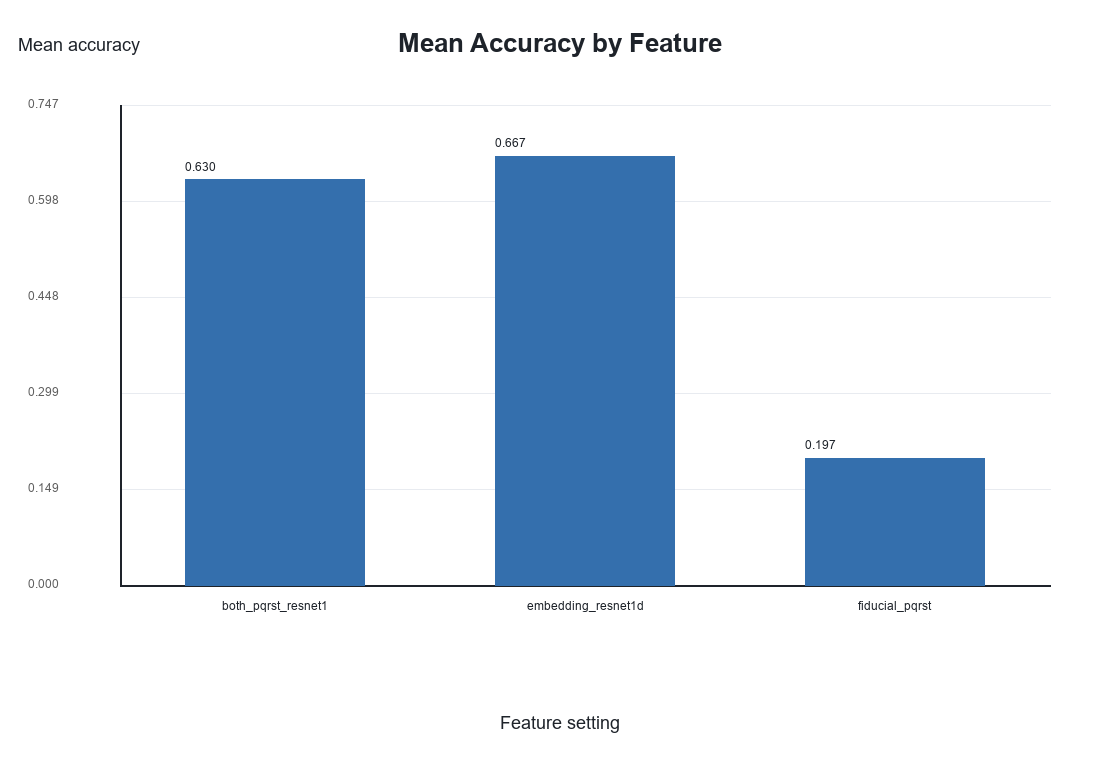

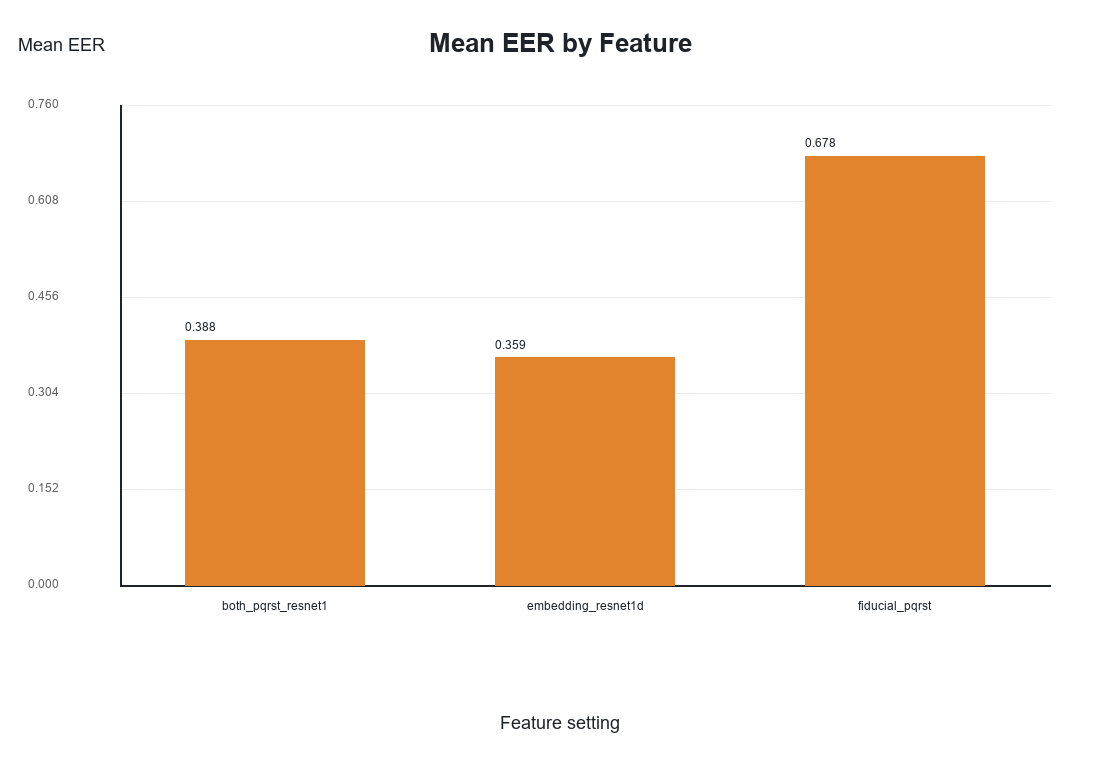

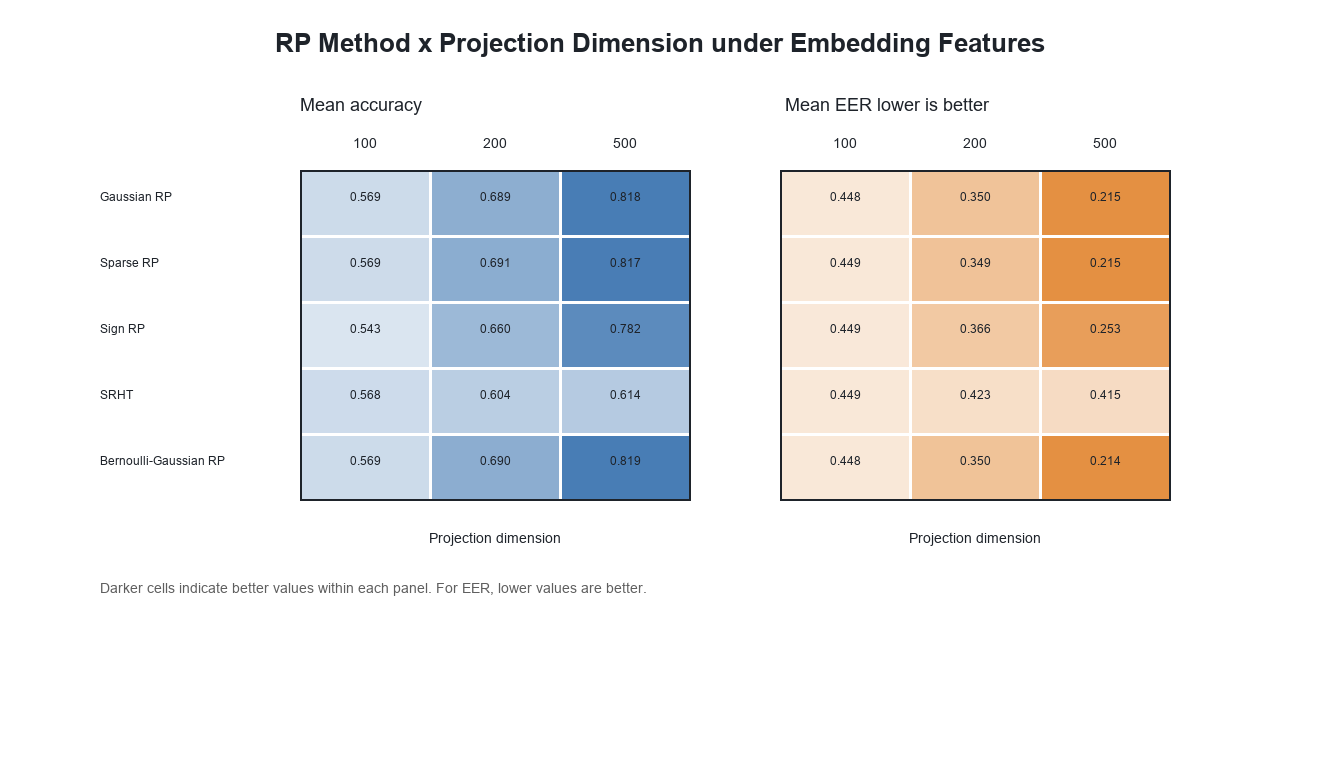

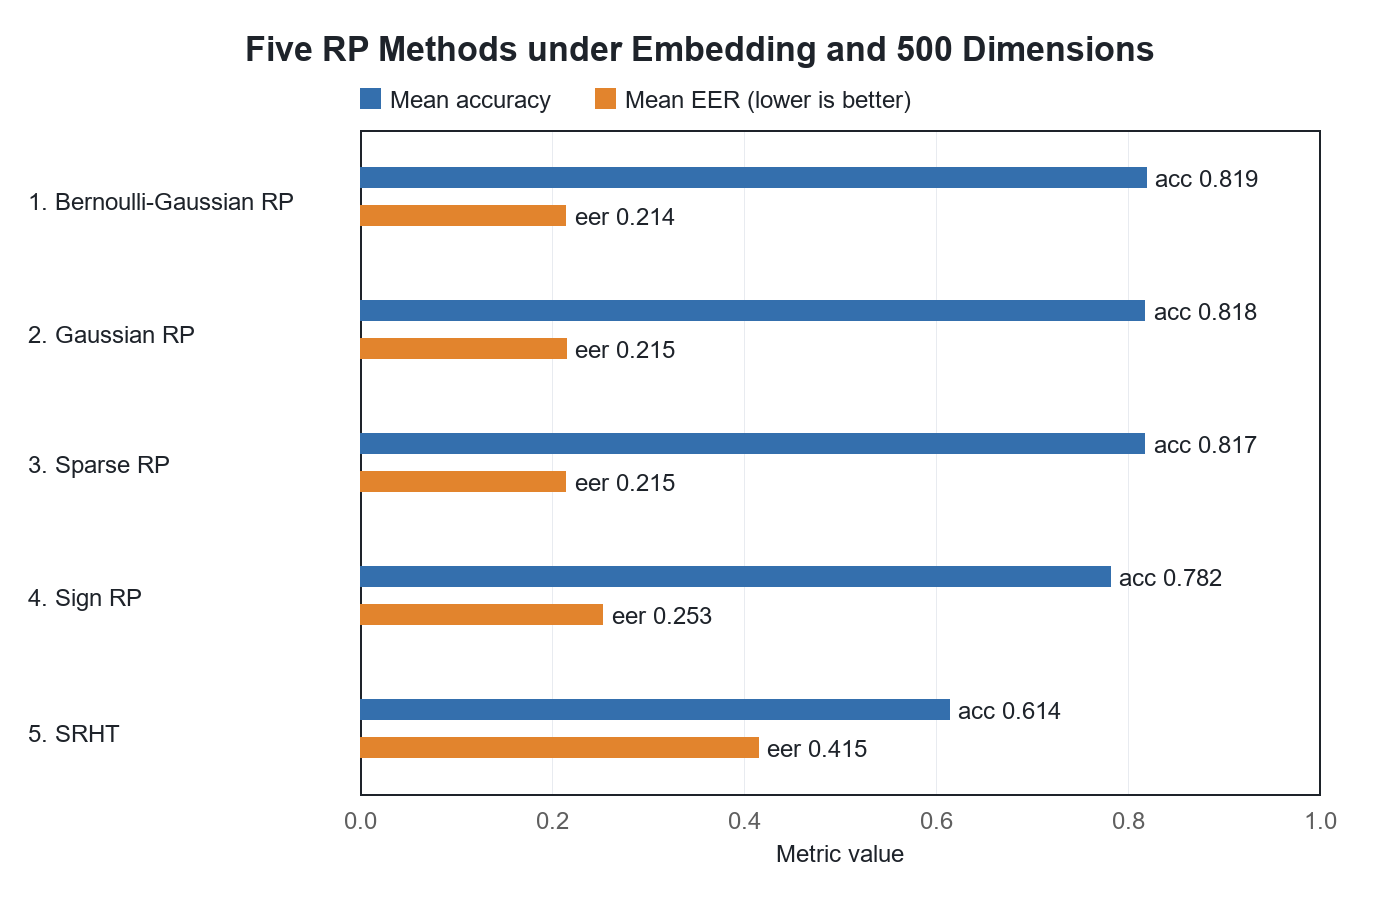

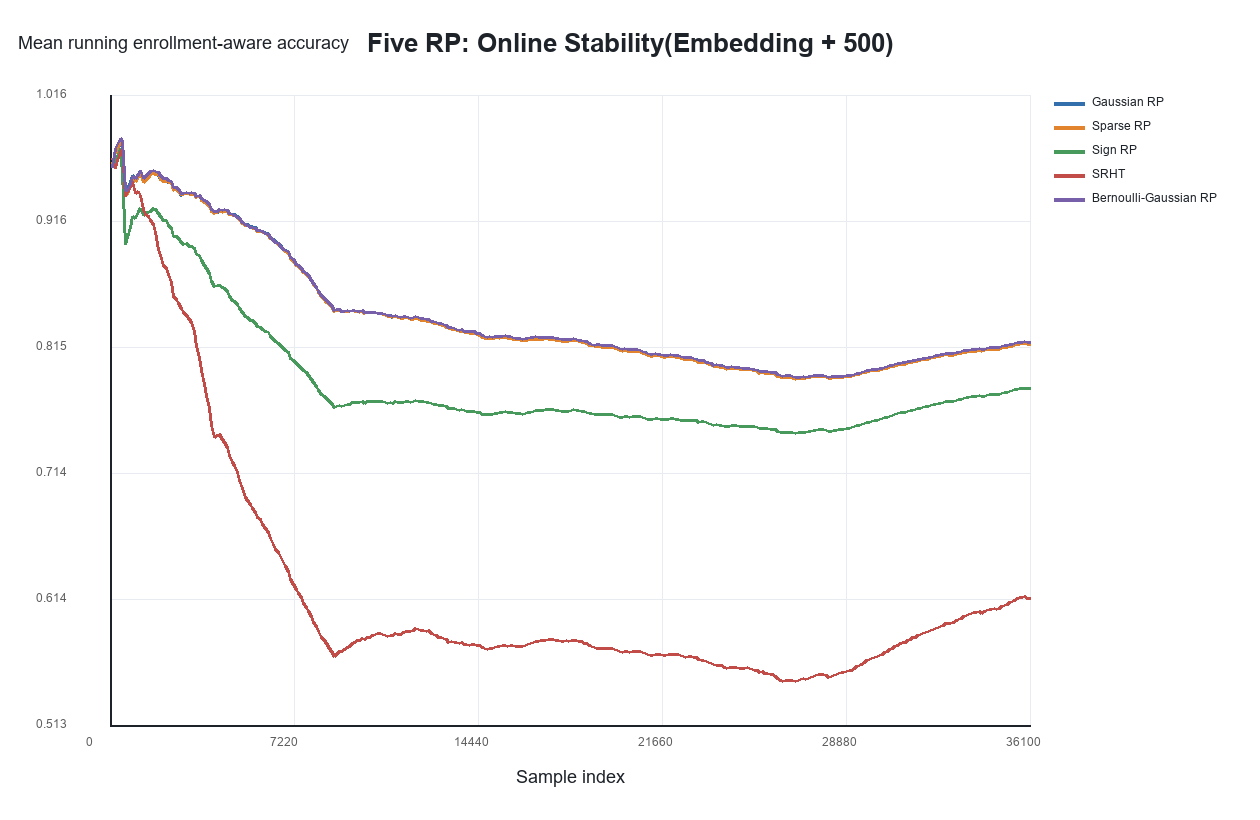

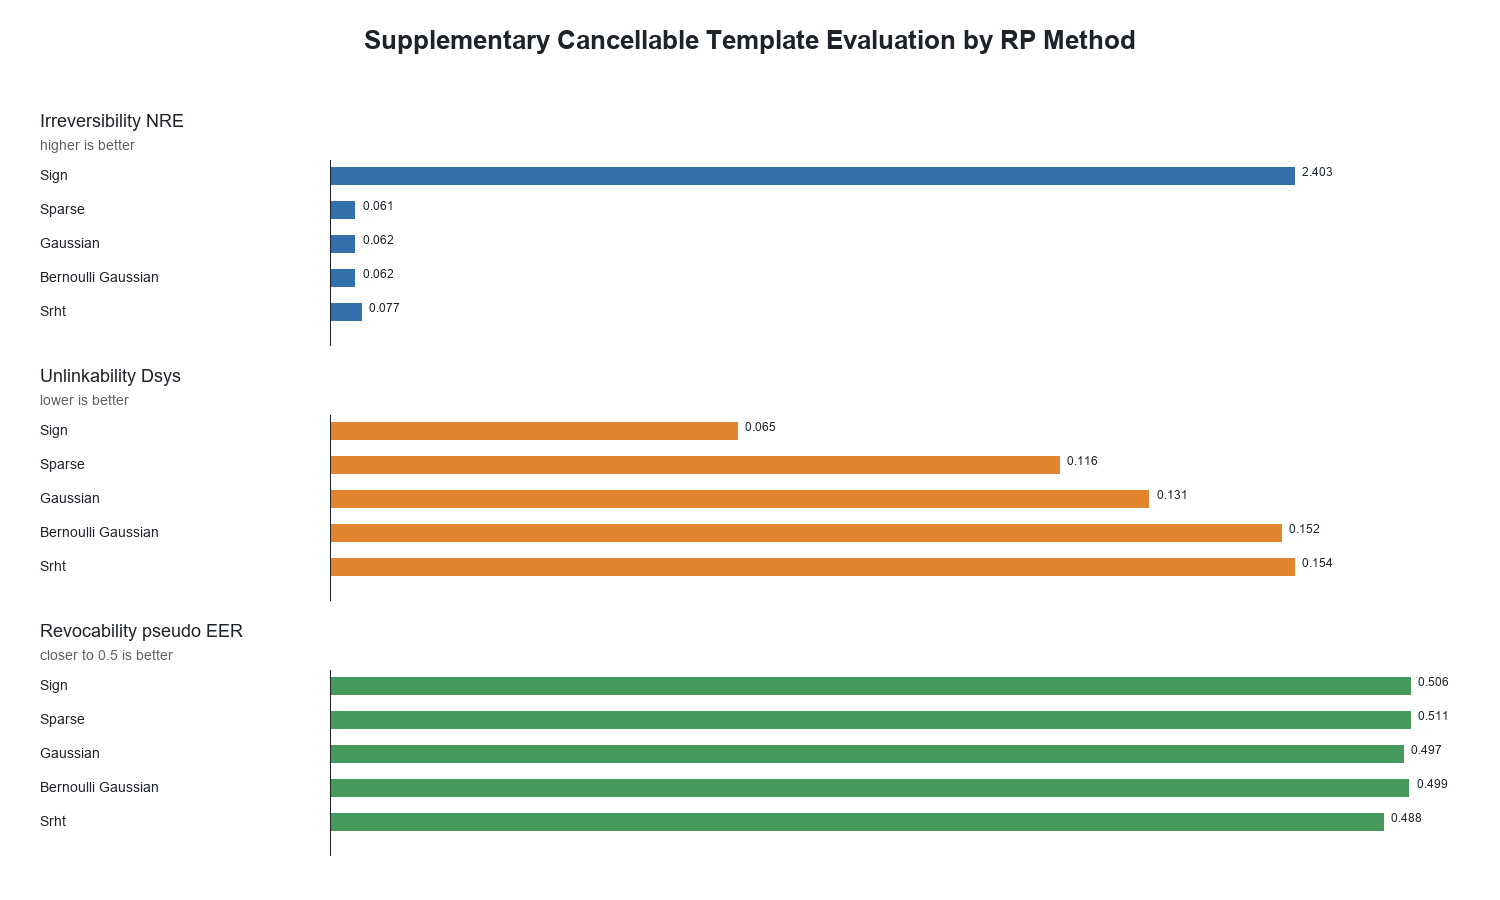

In [18]:
demo_show_title(
    "Key figures generated by Step 8",
    "These figures are saved outputs from this notebook and correspond to the thesis Chapter 4 results."
)

DEMO_FIGURES = [
    (FIGURE_DIR / "acc_by_feature.png", "Feature representation: mean accuracy"),
    (FIGURE_DIR / "eer_by_feature.png", "Feature representation: mean EER"),
    (FIGURE_DIR / "rp_dim_heatmap_emb_acc_eer.png", "RP method × dimension interaction under embedding features"),
    (FIGURE_DIR / "rp_controlled_emb_d500_acc_eer.png", "Controlled RP comparison: embedding + 500D"),
    (FIGURE_DIR / "rp_stability_emb_d500.png", "Online stability: embedding + 500D"),
    (FIGURE_DIR / "security_evaluation_by_method.png", "Template protection evaluation by RP method"),
]

for fig_path, fig_title in DEMO_FIGURES:
    demo_existing_figure(fig_path, fig_title, width=900)


## 16. Small code-based result viewer

This cell works like a simple front-end for the defense demo. Change the three variables below, run the cell, and the notebook will show the selected experiment combination and its useful metrics.

Available choices:

- `FEATURE_CHOICE`: `fiducial_pqrst`, `embedding_resnet1d`, `both_pqrst_resnet1d`
- `RP_METHOD_CHOICE`: `gaussian`, `sparse`, `sign`, `srht`, `bernoulli_gaussian`
- `PROJECTION_DIM_CHOICE`: `100`, `200`, `500`


In [20]:
# ===== Change these three values during the live demo =====
FEATURE_CHOICE = "fiducial_pqrst"
RP_METHOD_CHOICE = "sign"
PROJECTION_DIM_CHOICE = 200
# =========================================================


def demo_match_column(df, col, choice):
    if col not in df.columns:
        return pd.Series([False] * len(df), index=df.index)
    target = demo_clean_key(choice)
    return df[col].map(demo_clean_key).eq(target)


def demo_setting_mask(df, feature_choice, rp_choice, dim_choice):
    feature_mask = demo_match_column(df, "feature_setting_full", feature_choice)
    if "feature_alias" in df.columns:
        feature_alias_map = {
            "fiducial_pqrst": "fid", "embedding_resnet1d": "emb", "both_pqrst_resnet1d": "both",
            "fid": "fid", "emb": "emb", "both": "both",
        }
        feature_mask = feature_mask | demo_match_column(df, "feature_alias", feature_alias_map.get(str(feature_choice), feature_choice))

    rp_mask = demo_match_column(df, "rp_method_full", rp_choice)
    if "rp_alias" in df.columns:
        rp_alias_map = {
            "gaussian": "gauss", "gauss": "gauss",
            "sparse": "sparse", "sign": "sign", "srht": "srht",
            "bernoulli_gaussian": "bg", "bg": "bg",
        }
        rp_mask = rp_mask | demo_match_column(df, "rp_alias", rp_alias_map.get(str(rp_choice), rp_choice))

    dim_mask = df["projection_dim"].astype(int).eq(int(dim_choice)) if "projection_dim" in df.columns else False
    return feature_mask & rp_mask & dim_mask


def demo_interpretation(feature_choice, rp_choice, dim_choice):
    rp_key = demo_clean_key(rp_choice)
    dim = int(dim_choice)
    lines = []
    if demo_clean_key(feature_choice) == demo_clean_key("embedding_resnet1d"):
        lines.append("Feature: ResNet1D embedding is the strongest representation in this thesis because it keeps richer waveform information.")
    elif demo_clean_key(feature_choice) == demo_clean_key("fiducial_pqrst"):
        lines.append("Feature: PQRST fiducial is interpretable, but it is compact and loses detailed waveform information.")
    else:
        lines.append("Feature: Combined features test whether handcrafted features add useful information beyond the embedding.")

    if rp_key in [demo_clean_key("bernoulli_gaussian"), demo_clean_key("bg")]:
        lines.append("RP method: Bernoulli-Gaussian is recognition-oriented and gives the highest mean recognition result.")
    elif rp_key == demo_clean_key("sign"):
        lines.append("RP method: Sign RP is protection-oriented. It removes magnitude information, so protection improves but recognition drops.")
    elif rp_key == demo_clean_key("sparse"):
        lines.append("RP method: Sparse RP is a balanced option. It stays close to the strongest recognition group and gives better unlinkability.")
    elif rp_key in [demo_clean_key("gaussian"), demo_clean_key("gauss")]:
        lines.append("RP method: Gaussian RP is a stable dense baseline and remains close to the strongest recognition group.")
    elif rp_key == demo_clean_key("srht"):
        lines.append("RP method: SRHT is weaker in this tested setting, possibly due to dimension, padding and implementation conditions.")

    if dim == 500:
        lines.append("Dimension: 500D gives the strongest recognition performance within the tested range, but it costs more runtime and template size.")
    elif dim == 200:
        lines.append("Dimension: 200D is a lighter middle option between recognition utility and efficiency.")
    else:
        lines.append("Dimension: 100D is the most compact setting, but it loses more identity information.")
    return lines

selected = demo_mean_std[demo_setting_mask(demo_mean_std, FEATURE_CHOICE, RP_METHOD_CHOICE, PROJECTION_DIM_CHOICE)].copy()
if len(selected) != 1:
    raise ValueError(f"Expected one selected mean/std row, got {len(selected)}. Check the three choice variables.")
selected_row = selected.iloc[0]

# Pull seed-level runs for the selected setting.
seed_runs = demo_final_df[demo_setting_mask(demo_final_df, FEATURE_CHOICE, RP_METHOD_CHOICE, PROJECTION_DIM_CHOICE)].sort_values("seed").copy()

# Pull security indicators for the selected setting if available.
security_selected = pd.DataFrame()
if len(demo_security_by_setting) > 0:
    security_selected = demo_security_by_setting[demo_setting_mask(demo_security_by_setting, FEATURE_CHOICE, RP_METHOD_CHOICE, PROJECTION_DIM_CHOICE)].copy()

setting_name = demo_format_setting_row(selected_row)
demo_show_title("Selected experiment combination", setting_name)

cards = "".join([
    demo_metric_card("Accuracy", f"{selected_row['mean_enrollment_aware_accuracy']:.4f}", "mean over 3 seeds"),
    demo_metric_card("Macro F1", f"{selected_row['mean_enrollment_aware_macro_f1']:.4f}", "mean over 3 seeds"),
    demo_metric_card("EER", f"{selected_row['mean_enrollment_aware_eer']:.4f}", "lower is better"),
    demo_metric_card("Runtime", f"{selected_row['mean_runtime_seconds']:.2f}s", "relative runtime"),
    demo_metric_card("Seeds", f"{int(selected_row['num_seeds'])}", "multi-seed result"),
])

if len(security_selected) == 1:
    sec = security_selected.iloc[0]
    cards += "".join([
        demo_metric_card("NRE", f"{sec['normalized_reconstruction_error_mean']:.3f}", "higher is stronger"),
        demo_metric_card("Dsys", f"{sec['unlinkability_dsys_mean']:.3f}", "lower is stronger"),
        demo_metric_card("RevEER", f"{sec['revocability_pseudo_impostor_eer_mean']:.3f}", "closer to 0.5"),
    ])

display(HTML(cards))

# Short interpretation for oral presentation.
interpretation_lines = demo_interpretation(FEATURE_CHOICE, RP_METHOD_CHOICE, PROJECTION_DIM_CHOICE)
display(HTML("<div style='padding:10px 14px; background:#fff8e6; border-left:6px solid #f0ad4e;'>" + "<br>".join(interpretation_lines) + "</div>"))

# Show seed-level evidence.
seed_cols = [
    "seed", "enrollment_aware_accuracy", "enrollment_aware_macro_f1", "enrollment_aware_eer", "runtime_seconds"
]
seed_cols = [c for c in seed_cols if c in seed_runs.columns]
demo_display_df(seed_runs[seed_cols], "Seed-level runs for selected setting", max_rows=5)

# Show security row if available.
if len(security_selected) == 1:
    sec_cols = [
        "normalized_reconstruction_error_mean", "reconstruction_snr_db_mean",
        "unlinkability_dsys_mean", "revocability_pseudo_impostor_eer_mean"
    ]
    sec_cols = [c for c in sec_cols if c in security_selected.columns]
    demo_display_df(security_selected[sec_cols], "Template protection indicators for selected setting", max_rows=1)


,seed,enrollment_aware_accuracy,enrollment_aware_macro_f1,enrollment_aware_eer,runtime_seconds
37,27.0000,0.1962,0.1102,0.6835,6.9978
82,42.0000,0.1950,0.1102,0.6829,6.0873
127,82.0000,0.1937,0.1084,0.6819,6.6998


,normalized_reconstruction_error_mean,reconstruction_snr_db_mean,unlinkability_dsys_mean,revocability_pseudo_impostor_eer_mean
37,3.1835,-5.0286,0.1036,0.4927
